# Rare corruptions on MNIST-C: do difficulty scores find rare groups, and does acting on them help?

This notebook adapts the Section 5 experiments of *Leave No-One-Out: Context Modifications in Tabular Foundation Models* (Tables 2–4, Appendix D.1–D.5) to **MNIST-C** with a **rare-corruption design**:

* Each context has 6,000 digits (600 per class). 95% are clean (`identity`); 5% come from **R = 3 rare corruptions** (10 per digit per corruption).
* Corruption type is **independent of the class**. Errors on rare groups therefore come from **under-representation**, not from a spurious shortcut. This differs from Waterbirds and the paper's four-group construction, where the minority breaks a spurious correlation.
* Features are the 128-d penultimate layer of a small CNN trained **only on clean digits** that never appear in any context.
* Group labels are used only for evaluation, tail-composition reports, the oracle, and (clearly labelled) validation-based selection of τ/λ.

| Table here | Paper analogue | Question |
|---|---|---|
| A | Table 2 / D.1 / D.3 | Does difficulty-based reweighting help rare groups? |
| B | Table D.2 | What does the selected tail actually contain? |
| C | Table 3 / D.5 | Label noise: detection vs. editing value |
| D | Table 4 / D.4 | Like A, with a native TFM (TabICLv2) and context resampling |

These experiments measure **intervention value** (paper Section 2.2, Eq. 3). They do **not** measure the Section 4 audit error $E_i$.

### Running on Google Colab
1. *Runtime → Change runtime type*: choose a **GPU** and the **high-RAM** option. TabICL (Table D) is much faster on a GPU.
2. The repository is private: add a GitHub token as a Colab secret named `GITHUB_TOKEN` (key icon in the sidebar, notebook access on). The first code cell uses it to clone `interpret_tfm` (branch `BRANCH`) and install it, which provides `kernel_louis` and the KernelICL fork of `tabicl`. **Push any local changes to that branch first**, or Colab will run the old code.
3. Run once with `SMOKE_TEST = True` (2 seeds, reduced grids). Then set `SMOKE_TEST = False` for the full 10-seed run.
4. **Section 0 (Setup)** must run first. After a runtime reset, re-run Section 0. Then Sections 1, 3, 4 and 5 can each be run on their own. Section 2 (Table B) uses the scores from 1.1.

### Contents
0. Setup: install, configuration, helpers, checks, data, CNN, pilot, per-seed data
1. Table A: reweighting the rare-corruption context
2. Table B: what the selected tail contains
3. ρ sweep: how rare is too rare?
4. Table C: label noise
5. Table D: native TFM with context resampling
6. Sanity-check summary
7. Decisions
8. Results summary
9. Interpretation

# 0. Setup

## 0.1 Install and environment

In [1]:
# Clone the (private) repository on Colab and install it: kernel_louis plus the KernelICL
# fork of tabicl. numpy / torch / scikit-learn are already in Colab and are left alone.
#
# Access: add a GitHub token as a Colab secret named GITHUB_TOKEN (key icon in the left
# sidebar, notebook access on). It is read from there and never printed or stored in
# the clone's git config.
import os
import sys
import subprocess

REPO = "github.com/AndreaKarlova/interpret_tfm.git"
BRANCH = "main"
IN_COLAB = "google.colab" in sys.modules


def git(*args, token=None):
    """Run git; on failure, raise without echoing the token-bearing command."""
    result = subprocess.run(["git", *args], capture_output=True, text=True)
    if result.returncode != 0:
        message = result.stderr.replace(token, "***") if token else result.stderr
        raise RuntimeError(f"git {args[0]} failed:\n{message}")


if IN_COLAB:
    from google.colab import userdata

    REPO_DIR = "/content/interpret_tfm"
    token = userdata.get("GITHUB_TOKEN")
    authed = f"https://x-access-token:{token}@{REPO}"
    if not os.path.isdir(REPO_DIR):
        git("clone", "-q", "-b", BRANCH, authed, REPO_DIR, token=token)
        git("-C", REPO_DIR, "remote", "set-url", "origin", f"https://{REPO}")
    else:
        git("-C", REPO_DIR, "pull", "-q", authed, BRANCH, token=token)
    del token, authed

    # Never `pip install tabicl` on top: the PyPI package would shadow the fork.
    !pip install -q -e {REPO_DIR}
else:
    REPO_DIR = os.path.abspath("..")  # running locally from interpret_tfm/notebooks

# An editable install only takes effect after a runtime restart, so put the sources on
# the path directly as well.
for path in (os.path.join(REPO_DIR, "src"), REPO_DIR):
    if path not in sys.path:
        sys.path.insert(0, path)
print("using kernel_louis and tabicl from", REPO_DIR)

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for interpret_tfm (pyproject.toml) ... done
using kernel_louis and tabicl from /content/interpret_tfm


In [2]:
import time
import random
import platform

import numpy as np
import pandas as pd
import scipy
import sklearn
import torch
import matplotlib
import matplotlib.pyplot as plt
import psutil
from IPython.display import display

pd.set_option("display.max_rows", 500)
pd.set_option("display.width", 200)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
try:
    import tabicl
    TABICL_VERSION = tabicl.__version__
except ImportError:
    TABICL_VERSION = None

print(f"python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scipy {scipy.__version__} | scikit-learn {sklearn.__version__}")
print(f"torch {torch.__version__} | matplotlib {matplotlib.__version__} | tabicl {TABICL_VERSION}")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))
memory = psutil.virtual_memory()
print(f"RAM: {memory.total / 2**30:.1f} GB total, {memory.available / 2**30:.1f} GB available")
if DEVICE == "cpu":
    print("WARNING: no GPU found. Table D (TabICL) will be very slow on CPU. "
          "In Colab: Runtime -> Change runtime type -> GPU.")

python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3 | scikit-learn 1.6.1
torch 2.11.0+cu130 | matplotlib 3.10.0 | tabicl 2.1.1
device: cuda (NVIDIA A100-SXM4-80GB)
RAM: 167.1 GB total, 163.7 GB available


## 0.2 Configuration

All parameters in one place. Start with `SMOKE_TEST = True`.

In [3]:
# ----- run mode -----
SMOKE_TEST = False          # True: 2 seeds and reduced grids. Set False for the full run.
BACKEND = "tabicl"         # Table D model: "tabicl" (TabICLv2) or "stub" (logistic regression, quick check)
USE_DRIVE = True          # True: keep the data in Google Drive so it survives runtime resets
DATA_DIR = "/content/data"

# ----- seeds -----
SPLIT_SEED = 12345         # index splits and validation set (fixed for every experimental seed)
CNN_SEED = 0
PILOT_SEED = 999
SEEDS = [0, 1] if SMOKE_TEST else list(range(10))
TABLE_D_SEEDS = SEEDS      # if compute is limited: SEEDS[:5] (and report that)

# ----- data design -----
N_CLASSES = 10
N_PER_CLASS = 600          # context n = 6000
RHO = 0.05                 # rare fraction
R = 3                      # number of rare corruptions
TEST_PER_CLASS = 100       # 1,000 test digits, each in R + 1 versions
VAL_PER_CLASS = 100        # 1,000 validation digits, each in R + 1 versions
PILOT_VAL_IMAGES = 1000 if SMOKE_TEST else 5000
PILOT_MIN_ACC = 0.30

# ----- CNN and predictors -----
CNN_EPOCHS = 1 if SMOKE_TEST else 5
CNN_LR = 1e-3
CNN_BATCH = 128
LOGREG_C = 1.0
GAMMA_GRID_SIZE = 25               # kernel bandwidth candidates: gamma_median x geomspace(1, SPAN)
GAMMA_GRID_SPAN = 1e4

# ----- Table A / B -----
TAUS = [0.95] if SMOKE_TEST else [0.80, 0.90, 0.95, 0.97, 0.99]
LAMS = [8] if SMOKE_TEST else [2, 8, 20]
PRUNE_QS = [0.05] if SMOKE_TEST else [0.05, 0.10]
PRE_TAU, PRE_LAM = 0.95, 8         # pre-registered, group-label-free setting
SMOOTH_LAM = 10                    # paper Eq. D.3
EXP_BETA = 1.0                     # paper Eq. D.4
GP_SIGMA2 = 0.1                    # GP score noise used for interventions
GP_SIGMA2_SENSITIVITY = [0.1] if SMOKE_TEST else [0.01, 0.1, 1.0]
CROSSFIT_FOLDS = 5
RHOS = [0.01, 0.05] if SMOKE_TEST else [0.01, 0.025, 0.05, 0.10]

# ----- Table C -----
ETAS = [0.20] if SMOKE_TEST else [0.20, 0.40]
NOISE_TYPES = ["symmetric"] if SMOKE_TEST else ["symmetric", "asymmetric"]
LOW_DIM = 10

# ----- Table D -----
TFM_TAU = 0.95
TFM_LAMS = [8] if SMOKE_TEST else [3, 8, 15]
TFM_RANDOM_LAM = 8
TFM_DRAWS = 1 if SMOKE_TEST else 5

SANITY = {}    # sanity-check results, filled in by later sections
RUN_LOG = []   # run-dependent notes: fallbacks, zero denominators, ...

## 0.3 Helper functions

Most of the reusable code is in the `kernel_louis` package (cloned above), so it is tested (`tests/test_rare_corruption.py`) and shared with the other notebooks:

| Module | What it provides here |
|---|---|
| `kernel_louis.mnist_c` | download, label check (sanity check 1), index splits, context / paired-test builders (sanity check 2), label flips |
| `kernel_louis.cnn` | the CNN, its training on clean digits, feature extraction |
| `kernel_louis.kernels`, `heads` | Gaussian (log-)kernel, median heuristic, stable multiclass kernel head (Eq. 4 / 13) |
| `kernel_louis.loo` | soft-vote score (Eq. 9), multiclass GP score (Eq. A.20), cross-fitted score |
| `kernel_louis.modulation` | tail / random-tail / prune / pseudo-group / oracle multipliers, smooth and exponential rules (Eq. D.2–D.4), resampling (Eq. D.5) |
| `kernel_louis.evaluation` | per-group accuracy metrics, detection AUC, tail composition, mean ± SE and paired differences over seeds |
| `kernel_louis.predictors` | weighted logistic regression, 1-NN, TabICL / stub |

The cells below hold only the experiment-specific glue.

In [4]:
# --- Imports from kernel_louis ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score

from kernel_louis import mnist_c
from kernel_louis.cnn import train_cnn, extract_features
from kernel_louis.kernels import (gaussian_kernel, log_gaussian_kernel, median_heuristic_gamma,
                                  squared_distances)
from kernel_louis.heads import kernel_head_proba
from kernel_louis.loo import (crossfit_difficulty, frozen_loo_proba, frozen_loo_score,
                              loo_kernel_from_log, select_gamma_loo,
                              gp_loo_precision, gp_loo_score_multiclass)
from kernel_louis.modulation import (tail_multiplier, random_tail_multiplier, prune_multiplier,
                                     random_prune_multiplier, top_fraction_mask, pseudo_group_balance,
                                     group_balance_multiplier, smooth_multiplier, exponential_multiplier,
                                     surprisal_from_score, resample_context)
from kernel_louis.evaluation import (group_accuracy_metrics, detection_auc, tail_composition,
                                     weight_perplexity, mean_and_se, paired_differences)
from kernel_louis.predictors import (make_logreg, fit_weighted_logreg, one_nn_predict,
                                     make_tfm, tfm_fit_predict)
from kernel_louis.embeddings import extract_symmetric_embeddings

METRICS = ["worst_group", "balanced_mean", "context_mean", "worst_cell"]
GROUP_METRICS = [f"acc_g{k}" for k in range(R + 1)]

In [5]:
# --- General helpers ---
def set_all_seeds(seed):
    """Seed numpy's global RNG, Python's random module and torch."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)


def settings_of(intervention):
    """An intervention dict without its multiplier vector m, for the results table."""
    return {key: value for key, value in intervention.items() if key != "m"}


def add_rows(rows, results_by_eval_set, **info):
    """Append one flat result dict per evaluation set: info + eval_set + metrics."""
    for eval_set, metrics in results_by_eval_set.items():
        rows.append({**info, "eval_set": eval_set, **metrics})


def mean_se_table(summary, label_cols, metrics):
    """Readable table: label columns plus one 'mean ± SE' text column per metric."""
    table = summary[label_cols].copy()
    for metric in metrics:
        means, ses = summary[f"{metric}_mean"], summary[f"{metric}_se"]
        table[metric] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(means, ses)]
    table["n_seeds"] = summary["n_seeds"]
    return table.reset_index(drop=True)

In [6]:
# --- Features and per-seed data (used in 0.8) ---
def cnn_features(model, root, split, idx, version):
    """128-d CNN features of images idx[k] taken from folder version[k] of a split."""
    images = mnist_c.gather_images(root, split, idx, version)
    return extract_features(model, images, DEVICE)


def context_counts(rho, n_rare):
    """Images per digit for [identity, rare_1, ..., rare_R] at rare fraction rho."""
    r = mnist_c.rare_per_class(N_PER_CLASS, rho, n_rare)
    return [N_PER_CLASS - n_rare * r] + [r] * n_rare


def choose_gamma(X_ctx, y_ctx, log):
    """Kernel bandwidth for one context. Returns (gamma, gamma_median):
    gamma        maximises the mean frozen-LOO log-likelihood (Eq. 9) on the context (main);
    gamma_median = 1 / median nonzero squared distance, the paper's median heuristic (secondary).
    Uses only the context labels, never group labels or test data."""
    sq = squared_distances(X_ctx, X_ctx)
    pairs = sq[np.triu_indices(len(X_ctx), k=1)]
    gamma_median = 1.0 / np.median(pairs[pairs > 0])
    gammas = gamma_median * np.geomspace(1, GAMMA_GRID_SPAN, GAMMA_GRID_SIZE)
    gamma, _ = select_gamma_loo(sq, y_ctx, N_CLASSES, gammas)
    if gamma in (gammas[0], gammas[-1]):
        log.append(f"gamma selection hit the edge of its grid ({gamma / gamma_median:.3g} x median rule)")
    return gamma, gamma_median


def prepare_seed(seed, model, root, splits, labels, versions, val_raw, log):
    """Everything fixed within one seed: rare-corruption context, paired test set, balanced
    reference context, standardised features (scaler fit on the context only), gamma, log-kernels."""
    rng = np.random.default_rng(seed)
    n_rare = len(versions) - 1
    test_pool = np.arange(len(labels["test"]))
    ctx = mnist_c.build_context(splits["context"], labels["train"], versions, context_counts(RHO, n_rare), rng)
    test = mnist_c.build_paired_set(test_pool, labels["test"], versions, TEST_PER_CLASS, rng)
    bal = mnist_c.build_context(splits["context"], labels["train"], versions,
                                [N_PER_CLASS // len(versions)] * len(versions), rng)
    F_ctx = cnn_features(model, root, "train", ctx["idx"], ctx["version"])
    F_test = cnn_features(model, root, "test", test["idx"], test["version"])
    F_bal = cnn_features(model, root, "train", bal["idx"], bal["version"])
    scaler = StandardScaler().fit(F_ctx)
    d = {"seed": seed, "ctx": ctx, "test": test, "bal": bal, "F_test_raw": F_test,
         "X_ctx": scaler.transform(F_ctx), "X_test": scaler.transform(F_test),
         "X_val": scaler.transform(val_raw), "X_bal": scaler.transform(F_bal),
         "rho": float(np.mean(ctx["g"] > 0))}
    # gamma is chosen once on the baseline context and then fixed for the seed.
    d["gamma"], d["gamma_median"] = choose_gamma(d["X_ctx"], ctx["y"], log)
    d["logK_ctx"] = log_gaussian_kernel(d["X_ctx"], d["X_ctx"], d["gamma"])
    for name in ["test", "val"]:
        d[f"logK_{name}"] = log_gaussian_kernel(d[f"X_{name}"], d["X_ctx"], d["gamma"])
        d[f"logK_{name}_bal"] = log_gaussian_kernel(d[f"X_{name}"], d["X_bal"], d["gamma"])
    return d

In [7]:
# --- Difficulty scores (used in Sections 1-5) ---
def soft_vote_score(log_K_ctx, y, log):
    """Frozen-head difficulty L_i = 1 - p^{fr,-i}(y_i), paper Eq. 9 (kernel held fixed)."""
    L, n_zero = frozen_loo_score(loo_kernel_from_log(log_K_ctx), y, N_CLASSES)  # stable for large gamma
    if n_zero > 0:
        log.append(f"soft-vote score: {n_zero} zero denominators (L_i set to 1)")
    return L


def gp_score(log_K_ctx, y, sigma2):
    """Multiclass GP leave-one-out score, paper Eq. A.20 (one-hot targets, noise sigma2)."""
    Q = gp_loo_precision(np.exp(log_K_ctx), sigma2)
    return gp_loo_score_multiclass(Q, y, N_CLASSES)


def crossfit_score(estimator, X, y, seed, max_threads=None):
    """Cross-fitted L_i = 1 - p(y_i): each fold is predicted by a model fit on the other folds.
    max_threads=1 speeds up small models (logistic regression) when thread pools compete."""
    _, p_true = crossfit_difficulty(estimator, X, y, n_splits=CROSSFIT_FOLDS,
                                    random_state=seed, return_probs=True, max_threads=max_threads)
    return 1.0 - p_true


def tabicl_embedding_score(X_ctx, y, seed, log):
    """Eq. 9 on TabICL query-role embeddings (hook on icl_predictor.tf_icl), gamma = median heuristic.
    NOT label-honest: each point's own label is in the context when it is embedded.
    Returns (L, gamma), or (None, None) if the hook fails."""
    try:
        E, _ = extract_symmetric_embeddings(make_tfm("tabicl", seed, DEVICE), X_ctx, y)
    except Exception as e:
        log.append(f"seed {seed}: TabICL embedding hook failed ({type(e).__name__}: {e}); "
                   "Table D then uses only the cross-fitted score")
        return None, None
    E = E.astype(np.float64)
    gamma = median_heuristic_gamma(E, max_samples=None, factor=1.0)
    return frozen_loo_score(gaussian_kernel(E, E, gamma), y, N_CLASSES)[0], gamma

In [8]:
# --- Evaluating predictors on several evaluation sets (used in Sections 1 and 3) ---
def evaluate_kernel(log_kernels, targets, y_ctx, m, rho):
    """Kernel-head metrics (Eq. 13 with multipliers m) on each evaluation set.
    log_kernels and targets are dicts keyed by evaluation-set name ("test", "val")."""
    results = {}
    for name, log_K in log_kernels.items():
        proba, n_zero = kernel_head_proba(log_K, y_ctx, N_CLASSES, m=m)
        y_eval, g_eval = targets[name]
        results[name] = group_accuracy_metrics(proba.argmax(axis=1), y_eval, g_eval, R + 1, rho)
        results[name]["n_zero"] = n_zero  # uniform-fallback rows, logged in the results table
    return results


def evaluate_logreg(X_ctx, y_ctx, m, inputs, targets, rho):
    """Fit weighted logistic regression once (sample_weight = m) and score each evaluation set."""
    clf = fit_weighted_logreg(X_ctx, y_ctx, m, C=LOGREG_C)
    results = {}
    for name, X_eval in inputs.items():
        y_eval, g_eval = targets[name]
        results[name] = group_accuracy_metrics(clf.predict(X_eval), y_eval, g_eval, R + 1, rho)
    return results

In [9]:
# --- Section 1 (Table A): interventions ---
def table_a_interventions(L, y, g, probability_score, rng):
    """Every Table A multiplier vector for one score, as dicts: intervention name, its settings
    (tau, lam, q, beta), the realised tail size, and the multipliers m."""
    n = len(y)
    rows = [dict(intervention="baseline", m=np.ones(n))]
    for tau in TAUS:
        for lam in LAMS:
            m = tail_multiplier(L, lam, tau)
            size = int(np.sum(m > 1))  # ties can make this differ from (1 - tau) * n
            rows.append(dict(intervention="tail", tau=tau, lam=lam, tail_size=size, m=m))
            rows.append(dict(intervention="random_tail", tau=tau, lam=lam, tail_size=size,
                             m=random_tail_multiplier(n, size, lam, rng)))
    for q in PRUNE_QS:
        rows.append(dict(intervention="prune", q=q, m=prune_multiplier(L, q)))
        rows.append(dict(intervention="prune_random", q=q, m=random_prune_multiplier(n, q, rng)))
    rows.append(dict(intervention="pseudo_group_balance", tau=0.95, m=pseudo_group_balance(y, L, 0.95)))
    rows.append(dict(intervention="oracle_balance", m=group_balance_multiplier(g)))
    if probability_score:  # smooth / exponential need L of the form 1 - p
        s = surprisal_from_score(L)
        if np.ptp(s) == 0:
            print("note: surprisal is constant, so s~ = 0 and smooth/exponential equal the baseline")
        rows.append(dict(intervention="smooth", lam=SMOOTH_LAM, m=smooth_multiplier(s, SMOOTH_LAM)))
        rows.append(dict(intervention="exponential", beta=EXP_BETA, m=exponential_multiplier(s, EXP_BETA)))
    return rows


def condition_name(row):
    """Readable label of a results row, e.g. 'tail(0.95, 8)' or 'prune(0.05)'."""
    name = row["intervention"]
    if name in ("tail", "random_tail"):
        return f"{name}({row['tau']:g}, {row['lam']:g})"
    if name in ("prune", "prune_random"):
        return f"{name}({row['q']:g})"
    if name == "smooth":
        return f"smooth({row['lam']:g})"
    if name == "exponential":
        return f"exponential({row['beta']:g})"
    return name

In [10]:
# --- Section 1 (Table A): validation selection and main-table rows ---
def select_on_validation(df, predictor, score):
    """(tau, lam) of the tail rule with the best validation worst-group accuracy, averaged over
    seeds. This uses group labels, so the result is NOT group-label-free."""
    val = df[(df.eval_set == "val") & (df.predictor == predictor) & (df.score == score)
             & (df.intervention == "tail")]
    return val.groupby(["tau", "lam"])["worst_group"].mean().idxmax()


def main_conditions(selected):
    """(condition, how it was chosen) for the main Table A rows."""
    tau_s, lam_s = selected
    rows = [("baseline", ""),
            (f"tail({PRE_TAU:g}, {PRE_LAM:g})", "pre-registered"),
            (f"random_tail({PRE_TAU:g}, {PRE_LAM:g})", "control for pre-registered"),
            (f"tail({tau_s:g}, {lam_s:g})", "validation-selected (uses group labels)"),
            (f"random_tail({tau_s:g}, {lam_s:g})", "control for validation-selected")]
    for q in PRUNE_QS:
        rows += [(f"prune({q:g})", ""), (f"prune_random({q:g})", "control")]
    rows += [("pseudo_group_balance", "group-label-free"),
             ("oracle_balance", "uses group labels"),
             ("balanced_context_ref", "uses group labels"),
             (f"smooth({SMOOTH_LAM:g})", ""), (f"exponential({EXP_BETA:g})", "")]
    return rows


def table_a_main(summary, predictor, score, conditions):
    """Rows of `summary` for one predictor/score, in the order of `conditions`, with a 'setting' column."""
    picked = []
    for condition, setting in conditions:
        match = summary[(summary.predictor == predictor) & (summary.score == score)
                        & (summary.condition == condition)]
        if len(match) > 0:
            row = match.iloc[0].copy()
            row["setting"] = setting
            picked.append(row)
    return pd.DataFrame(picked).reset_index(drop=True)

In [11]:
# --- Section 3 (rho sweep) ---
def run_rho_context(seed, rho, model, root, splits, labels, versions, d, log):
    """One rho-sweep context: baseline, tail, random tail and oracle balance for the kernel head
    (soft-vote score) and logistic regression (cross-fitted score). Uses the seed's test set."""
    rng = np.random.default_rng([seed, int(round(rho * 1000))])
    ctx = mnist_c.build_context(splits["context"], labels["train"], versions,
                                context_counts(rho, len(versions) - 1), rng)
    F_ctx = cnn_features(model, root, "train", ctx["idx"], ctx["version"])
    scaler = StandardScaler().fit(F_ctx)  # refit for this context (declared default, see Section 7)
    X_ctx, X_test = scaler.transform(F_ctx), scaler.transform(d["F_test_raw"])
    y, g, rho_real = ctx["y"], ctx["g"], float(np.mean(ctx["g"] > 0))
    gamma, _ = choose_gamma(X_ctx, y, log)  # chosen for this context, like its scaler
    log_K_ctx = log_gaussian_kernel(X_ctx, X_ctx, gamma)
    log_K_test = log_gaussian_kernel(X_test, X_ctx, gamma)
    targets = {"test": (d["test"]["y"], d["test"]["g"])}
    scores = {"kernel": soft_vote_score(log_K_ctx, y, log),
              "logreg": crossfit_score(make_logreg(LOGREG_C), X_ctx, y, seed, max_threads=1)}
    rows = []
    for predictor, L in scores.items():
        info = dict(seed=seed, rho=rho, rho_realised=rho_real, predictor=predictor,
                    detection_auc=detection_auc(L, g > 0))
        m_tail = tail_multiplier(L, PRE_LAM, PRE_TAU)
        m_random = random_tail_multiplier(len(y), int(np.sum(m_tail > 1)), PRE_LAM, rng)
        for name, m in [("baseline", None), ("tail", m_tail), ("random_tail", m_random),
                        ("oracle_balance", group_balance_multiplier(g))]:
            if predictor == "kernel":
                results = evaluate_kernel({"test": log_K_test}, targets, y, m, rho_real)
            else:
                results = evaluate_logreg(X_ctx, y, m, {"test": X_test}, targets, rho_real)
            add_rows(rows, results, intervention=name, **info)
    return rows

In [12]:
# --- Section 4 (Table C): inputs and edited contexts ---
def table_c_inputs(d, dim, seed, log):
    """Features, kernels and GP precision for one feature dimension (full CNN or PCA(LOW_DIM)).
    gamma is chosen on the clean-label context and then held fixed for every noise setting."""
    if dim == LOW_DIM:
        pca = PCA(LOW_DIM, random_state=seed).fit(d["X_ctx"])  # fit on the seed's context only
        X_ctx, X_test = pca.transform(d["X_ctx"]), pca.transform(d["X_test"])
        gamma, _ = choose_gamma(X_ctx, d["ctx"]["y"], log)
        log_K_ctx = log_gaussian_kernel(X_ctx, X_ctx, gamma)
        log_K_test = log_gaussian_kernel(X_test, X_ctx, gamma)
    else:
        X_ctx, X_test, log_K_ctx, log_K_test = d["X_ctx"], d["X_test"], d["logK_ctx"], d["logK_test"]
    # The frozen LOO uses the row-rescaled kernel (stable); the GP needs the kernel itself.
    return {"X_ctx": X_ctx, "X_test": X_test, "log_K_test": log_K_test,
            "K_loo": loo_kernel_from_log(log_K_ctx), "Q": gp_loo_precision(np.exp(log_K_ctx), GP_SIGMA2)}


def table_c_edits(y_clean, y_noisy, flipped, L_by_score, P_loo, eta, rng):
    """Edited contexts for Table C as dicts: row name, score used, labels y, kept points keep."""
    n = len(y_clean)
    everyone = np.ones(n, dtype=bool)
    edits = [dict(row="clean_label_ref", score="none", y=y_clean, keep=everyone),
             dict(row="noisy_baseline", score="none", y=y_noisy, keep=everyone),
             dict(row="prune_random_q", score="none", y=y_noisy,
                  keep=random_prune_multiplier(n, eta, rng) > 0),
             dict(row="oracle_drop_flipped", score="none", y=y_noisy, keep=~flipped)]
    relabelled = P_loo.argmax(axis=1)  # argmax of the frozen LOO soft-vote prediction
    for score, L in L_by_score.items():
        top = top_fraction_mask(L, eta)  # q = eta (declared default, see Section 7)
        edits.append(dict(row="prune_top_q", score=score, y=y_noisy, keep=~top))
        edits.append(dict(row="relabel_top_q", score=score, y=np.where(top, relabelled, y_noisy),
                          keep=everyone))
    return edits

In [13]:
# --- Section 4 (Table C): evaluating an edited context ---
def evaluate_three(edit, inputs, targets, rho):
    """Kernel head, 1-NN and logistic regression, all on the same edited context."""
    y, keep = edit["y"], edit["keep"]
    proba, _ = kernel_head_proba(inputs["log_K_test"], y, N_CLASSES, m=keep.astype(float))
    predictions = {
        "kernel": proba.argmax(axis=1),
        "1nn": one_nn_predict(inputs["X_ctx"], y, inputs["X_test"], keep),
        "logreg": fit_weighted_logreg(inputs["X_ctx"], y, keep.astype(float), C=LOGREG_C).predict(inputs["X_test"]),
    }
    y_test, g_test = targets
    return {name: group_accuracy_metrics(pred, y_test, g_test, R + 1, rho)
            for name, pred in predictions.items()}

In [14]:
# --- Section 4 (Table C): one noise setting ---
def pruned_composition(keep, g, flipped):
    """2x2 composition of the pruned points: fractions {clean, rare} x {correct, flipped}."""
    pruned = ~keep
    out = {}
    for group_name, in_group in [("clean", g == 0), ("rare", g > 0)]:
        for label_name, label_mask in [("correct", ~flipped), ("flipped", flipped)]:
            out[f"{group_name}_{label_name}"] = float(np.mean(in_group[pruned] & label_mask[pruned]))
    return out


def run_noise_setting(seed, dim, noise, eta, inputs, d, group_names):
    """Flip labels, score them (soft-vote and GP), edit the context and evaluate every predictor.
    Returns (accuracy rows, detection-AUC rows, pruned-set composition rows)."""
    rng = np.random.default_rng([seed, dim, NOISE_TYPES.index(noise), int(round(eta * 100))])
    y, g = d["ctx"]["y"], d["ctx"]["g"]
    y_noisy, flipped = mnist_c.flip_labels(y, eta, noise, rng)
    P_loo, _ = frozen_loo_proba(inputs["K_loo"], y_noisy, N_CLASSES)
    L_by_score = {"soft_vote": 1.0 - P_loo[np.arange(len(y)), y_noisy],
                  "gp": gp_loo_score_multiclass(inputs["Q"], y_noisy, N_CLASSES)}
    info = dict(seed=seed, dim=dim, noise=noise, eta=eta)
    aucs = []
    for score, L in L_by_score.items():
        aucs.append({**info, "score": score, "group": "all", "auc": detection_auc(L, flipped)})
        for k, name in enumerate(group_names):
            aucs.append({**info, "score": score, "group": name,
                         "auc": detection_auc(L[g == k], flipped[g == k])})
    rows, comps = [], []
    targets = (d["test"]["y"], d["test"]["g"])
    for edit in table_c_edits(y, y_noisy, flipped, L_by_score, P_loo, eta, rng):
        for predictor, metrics in evaluate_three(edit, inputs, targets, d["rho"]).items():
            rows.append({**info, "predictor": predictor, "intervention": edit["row"],
                         "score": edit["score"], "eval_set": "test", **metrics})
        if edit["row"] == "prune_top_q":
            comps.append({**info, "score": edit["score"], **pruned_composition(edit["keep"], g, flipped)})
    return rows, aucs, comps

In [15]:
# --- Section 5 (Table D): context resampling ---
def table_d_settings(seed, scores, n):
    """(score, intervention, lam, m) for every resampling setting of Table D."""
    settings = [("none", "uniform_resample", np.nan, np.ones(n))]
    for score, L in scores.items():
        for lam in TFM_LAMS:
            settings.append((score, "tail_resample", lam, tail_multiplier(L, lam, TFM_TAU)))
    # Random control: same size as the tau = 0.95 tail of the cross-fitted score.
    tail_size = int(np.sum(tail_multiplier(scores["crossfit_tfm"], TFM_RANDOM_LAM, TFM_TAU) > 1))
    m_random = random_tail_multiplier(n, tail_size, TFM_RANDOM_LAM, np.random.default_rng([seed, 99]))
    settings.append(("none", "random_tail_resample", TFM_RANDOM_LAM, m_random))
    return settings


def run_resample_draw(seed, m, d, rng):
    """One resampled context: n rows drawn with replacement, probability proportional to m.
    Returns metrics for the TFM on the resampled rows, the frozen kernel head with the realised
    multiplicities c, and the kernel head with the deterministic multipliers m (paper Eq. D.7)."""
    y = d["ctx"]["y"]
    X_res, y_res, idx = resample_context(d["X_ctx"], y, m, target_unique=None, max_mult=None,
                                         rng=rng, return_indices=True)
    targets = {"test": (d["test"]["y"], d["test"]["g"])}
    prediction = tfm_fit_predict(BACKEND, seed, DEVICE, X_res, y_res, d["X_test"])
    counts = np.bincount(idx, minlength=len(y)).astype(float)
    kernel_test = {"test": d["logK_test"]}
    return {"tfm": group_accuracy_metrics(prediction, *targets["test"], R + 1, d["rho"]),
            "kernel_resampled": evaluate_kernel(kernel_test, targets, y, counts, d["rho"])["test"],
            "kernel_deterministic": evaluate_kernel(kernel_test, targets, y, m, d["rho"])["test"]}

In [16]:
# --- Plots: score boxplots ---
def plot_score_by_group(ax, L, g, group_names, title):
    """Boxplot of a difficulty score for each group (clean first, then the rare corruptions)."""
    ax.boxplot([L[g == k] for k in range(len(group_names))], showfliers=False)
    ax.set_xticks(range(1, len(group_names) + 1))
    ax.set_xticklabels(group_names, rotation=20)
    ax.set_ylabel("difficulty score $L_i$")
    ax.set_title(title)

In [17]:
# --- Plots: bars ---
def bar_colour(condition):
    """Grey baseline, orange for references that use group labels, light blue for random controls."""
    if condition == "baseline":
        return "grey"
    if condition.startswith(("oracle", "balanced_context")):
        return "tab:orange"
    if condition.startswith(("random", "prune_random")):
        return "lightsteelblue"
    return "tab:blue"


def plot_condition_bars(ax, table, metric, title):
    """Bars of mean ± SE of `metric` per condition, with the baseline as a dotted line."""
    x = np.arange(len(table))
    ax.bar(x, table[f"{metric}_mean"], yerr=table[f"{metric}_se"], capsize=3,
           color=[bar_colour(c) for c in table["condition"]])
    baseline = table.loc[table["condition"] == "baseline", f"{metric}_mean"]
    if len(baseline) > 0:
        ax.axhline(baseline.iloc[0], ls=":", c="k", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(table["condition"], rotation=40, ha="right", fontsize=8)
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(title)


def plot_group_accuracies(ax, rows, labels, group_names, title):
    """Grouped bars: accuracy on each group (x axis) for each summary row in `rows`."""
    width = 0.8 / len(rows)
    for j, (row, label) in enumerate(zip(rows, labels)):
        means = [row[f"acc_g{k}_mean"] for k in range(len(group_names))]
        ax.bar(np.arange(len(group_names)) + (j - (len(rows) - 1) / 2) * width, means, width, label=label)
    ax.set_xticks(range(len(group_names)))
    ax.set_xticklabels(group_names, rotation=20)
    ax.set_ylabel("test accuracy")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.set_title(title)

## 0.4 Correctness checks (sanity checks 5 and 6)

These run on a small random example and stop the notebook if they fail.
* **Check 5:** the closed-form score of Eq. 9 must equal brute-force frozen deletion: drop point *i*, renormalise, read off the probability of $y_i$ at $x_i$.
* **Check 6:** for a kernel on *fixed* features, deleting a point from the head (frozen) and recomputing the predictor without it must agree, i.e. $E_i = 0$ (paper Section 4.2, the analytical negative control).

In [18]:
rng = np.random.default_rng(0)
X_small, X_query = rng.normal(size=(40, 5)), rng.normal(size=(20, 5))
y_small = rng.integers(0, N_CLASSES, size=40)
gamma_small = median_heuristic_gamma(X_small, max_samples=None, factor=1.0)

# Check 5: Eq. 9 equals brute-force frozen deletion.
L_closed, _ = frozen_loo_score(gaussian_kernel(X_small, X_small, gamma_small), y_small, N_CLASSES)
for i in range(len(y_small)):
    keep = np.arange(len(y_small)) != i
    proba, _ = kernel_head_proba(log_gaussian_kernel(X_small[i:i + 1], X_small[keep], gamma_small),
                                 y_small[keep], N_CLASSES)
    assert abs(L_closed[i] - (1.0 - proba[0, y_small[i]])) < 1e-10, f"Eq. 9 != brute force at i={i}"
SANITY["5 Eq. 9 unit test"] = "pass"

# Check 6: on fixed features, frozen deletion (Eq. 5, via Eq. 8) equals recomputed deletion.
proba_full, _, W = kernel_head_proba(log_gaussian_kernel(X_query, X_small, gamma_small), y_small,
                                     N_CLASSES, return_weights=True)
for _ in range(20):
    i, x = rng.integers(len(y_small)), rng.integers(len(X_query))
    keep = np.arange(len(y_small)) != i
    frozen = (proba_full[x] - W[x, i] * np.eye(N_CLASSES)[y_small[i]]) / (1.0 - W[x, i])
    recomputed, _ = kernel_head_proba(log_gaussian_kernel(X_query[x:x + 1], X_small[keep], gamma_small),
                                      y_small[keep], N_CLASSES)
    assert np.max(np.abs(frozen - recomputed[0])) < 1e-10, f"fixed-feature control: E_i != 0 (i={i})"
SANITY["6 fixed-feature negative control"] = "pass"
print("check 5 (Eq. 9 unit test): pass | check 6 (E_i = 0 on fixed features, 20 pairs): pass")

check 5 (Eq. 9 unit test): pass | check 6 (E_i = 0 on fixed features, 20 pairs): pass


## 0.5 Data and index splits

Download MNIST-C (Zenodo record 3239543) and check that every folder has the expected shapes and **identical labels** (sanity check 1; the notebook stops if not). Then split the 60,000 training indices once, with `SPLIT_SEED`, into disjoint pools:

| Pool | Size | Use |
|---|---|---|
| validation | 5,000 (500 / digit) | pilot and τ/λ selection; never in a context |
| CNN | 20,000 (2,000 / digit) | trains the CNN on clean images; never in a context |
| context | 35,000 | contexts are sampled from here |

All 10,000 test indices form the test pool.

In [19]:
t0 = time.time()
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DATA_DIR = "/content/drive/MyDrive/mnist_c_data"
    except ImportError:
        print("USE_DRIVE = True but this is not Colab; keeping DATA_DIR =", DATA_DIR)

print("MNIST-C URL:", mnist_c.MNIST_C_URL)
MNIST_C_ROOT = mnist_c.download_mnist_c(DATA_DIR)
ALL_VERSIONS = mnist_c.list_versions(MNIST_C_ROOT)
CORRUPTION_NAMES = [v for v in ALL_VERSIONS if v != "identity"]
assert "identity" in ALL_VERSIONS, "no identity (clean) folder found"
print(f"{len(ALL_VERSIONS)} folders:", ALL_VERSIONS)
if sorted(CORRUPTION_NAMES) != sorted(mnist_c.CORRUPTIONS):
    print("NOTE: folder names differ from the expected 15:",
          sorted(set(CORRUPTION_NAMES) ^ set(mnist_c.CORRUPTIONS)))

LABELS = mnist_c.verify_mnist_c(MNIST_C_ROOT, ALL_VERSIONS)  # sanity check 1 (asserts)
SANITY["1 label equality across folders"] = "pass"
SPLITS = mnist_c.make_index_splits(LABELS["train"], SPLIT_SEED)
print({name: len(idx) for name, idx in SPLITS.items()}, "| test pool:", len(LABELS["test"]))
print(f"data ready ({time.time() - t0:.0f}s)")

Mounted at /content/drive
MNIST-C URL: https://zenodo.org/records/3239543/files/mnist_c.zip?download=1
MNIST-C already present at /content/drive/MyDrive/mnist_c_data/mnist_c
16 folders: ['brightness', 'canny_edges', 'dotted_line', 'fog', 'glass_blur', 'identity', 'impulse_noise', 'motion_blur', 'rotate', 'scale', 'shear', 'shot_noise', 'spatter', 'stripe', 'translate', 'zigzag']
{'val': 5000, 'cnn': 20000, 'context': 35000} | test pool: 10000
data ready (85s)


## 0.6 CNN feature extractor

`Conv(1→32) → ReLU → MaxPool → Conv(32→64) → ReLU → MaxPool → Linear(3136→128) → ReLU → Linear(128→10)`. It is trained once (`CNN_SEED`) with Adam (lr 1e-3, batch 128, 5 epochs, no augmentation) on the **clean** CNN-pool images only, with 10% of the pool held out to monitor accuracy, and then frozen. The 128-d ReLU output is the feature vector for every predictor.

The CNN never sees context, validation or test images. If it did, its features would already encode those images' true labels, which would inflate label-noise detection in Table C.

In [20]:
t0 = time.time()
set_all_seeds(CNN_SEED)
cnn_images = mnist_c.gather_images(MNIST_C_ROOT, "train", SPLITS["cnn"],
                                   np.full(len(SPLITS["cnn"]), "identity"))
CNN, CNN_HOLDOUT_ACC = train_cnn(cnn_images, LABELS["train"][SPLITS["cnn"]], seed=CNN_SEED,
                                 epochs=CNN_EPOCHS, lr=CNN_LR, batch_size=CNN_BATCH, device=DEVICE)
print(f"held-out clean accuracy: {CNN_HOLDOUT_ACC:.4f} ({time.time() - t0:.0f}s)")
if CNN_HOLDOUT_ACC < 0.95:
    print("WARNING: held-out accuracy is below 0.95 (expected about 0.98+ after 5 epochs).")

  epoch 1/5: last batch loss 0.113
  epoch 2/5: last batch loss 0.073
  epoch 3/5: last batch loss 0.112
  epoch 4/5: last batch loss 0.040
  epoch 5/5: last batch loss 0.042
held-out clean accuracy: 0.9790 (10s)


## 0.7 Pilot: choosing the rare corruptions

The pilot fits both main predictors (kernel head, with γ chosen as in 0.8, and logistic regression) on an **all-clean** 6,000-image context (seed 999). It evaluates them on the validation-pool images under every corruption, then ranks corruptions by the mean accuracy of the two predictors.

The rare corruptions are the **R lowest with accuracy > 0.30**: hard for a clean context, but not destroyed. They stay fixed for every seed.

In [21]:
t0 = time.time()
rng = np.random.default_rng(PILOT_SEED)
pilot_ctx = mnist_c.build_context(SPLITS["context"], LABELS["train"], ["identity"], [N_PER_CLASS], rng)
F_pilot = cnn_features(CNN, MNIST_C_ROOT, "train", pilot_ctx["idx"], pilot_ctx["version"])
pilot_scaler = StandardScaler().fit(F_pilot)
X_pilot = pilot_scaler.transform(F_pilot)
gamma_pilot, _ = choose_gamma(X_pilot, pilot_ctx["y"], RUN_LOG)
pilot_logreg = fit_weighted_logreg(X_pilot, pilot_ctx["y"], C=LOGREG_C)
pilot_val = np.sort(rng.choice(SPLITS["val"], size=PILOT_VAL_IMAGES, replace=False))
y_pilot_val = LABELS["train"][pilot_val]

pilot_rows = []
for version in ALL_VERSIONS:
    F_val = cnn_features(CNN, MNIST_C_ROOT, "train", pilot_val, np.full(len(pilot_val), version))
    X_val = pilot_scaler.transform(F_val)
    proba, _ = kernel_head_proba(log_gaussian_kernel(X_val, X_pilot, gamma_pilot), pilot_ctx["y"], N_CLASSES)
    pilot_rows.append({"corruption": version,
                       "kernel_acc": float(np.mean(proba.argmax(axis=1) == y_pilot_val)),
                       "logreg_acc": float(np.mean(pilot_logreg.predict(X_val) == y_pilot_val))})
PILOT = pd.DataFrame(pilot_rows)
PILOT["mean_acc"] = (PILOT["kernel_acc"] + PILOT["logreg_acc"]) / 2
PILOT = PILOT.sort_values("mean_acc").reset_index(drop=True)
print(f"pilot done ({time.time() - t0:.0f}s)")

pilot done (38s)


In [22]:
display(PILOT.round(3))
eligible = PILOT[(PILOT["corruption"] != "identity") & (PILOT["mean_acc"] > PILOT_MIN_ACC)]
assert len(eligible) >= R, (f"only {len(eligible)} corruptions have pilot accuracy > {PILOT_MIN_ACC}: "
                            "stop and report this")
RARE_CORRUPTIONS = eligible["corruption"].head(R).tolist()
VERSIONS = ["identity"] + RARE_CORRUPTIONS      # group g = position in this list
print("rare corruptions:", RARE_CORRUPTIONS)

,corruption,kernel_acc,logreg_acc,mean_acc
0,fog,0.121,0.400,0.261
1,translate,0.485,0.456,0.470
2,stripe,0.752,0.622,0.687
3,canny_edges,0.828,0.730,0.779
4,brightness,0.796,0.832,0.814
5,scale,0.798,0.875,0.837
6,motion_blur,0.817,0.865,0.841
7,glass_blur,0.781,0.910,0.845
8,impulse_noise,0.894,0.824,0.859
9,zigzag,0.890,0.858,0.874


rare corruptions: ['translate', 'stripe', 'canny_edges']


**How to read this:** each row is one MNIST-C version, scored by a model whose context contains only clean digits. Low accuracy means the clean context does not cover that corruption well, which is the situation the rare groups are meant to create. The chosen corruptions are the lowest rows above 0.30, excluding `identity`. Corruptions below 0.30 are excluded because they are too damaged for a few rare examples to help.

## 0.8 Per-seed data

For every experimental seed, this cell builds:
* the **rare-corruption context**: 600 digits per class; within each class, 570 clean and 10 per rare corruption, assigned at random;
* the **paired test set**: 100 test digits per class, each shown in all R + 1 versions, so every group has the same digits;
* the **balanced reference context**: 1,500 images per group;
* standardised CNN features (scaler fit on that seed's context only) and the log-kernels to the context;
* the **kernel bandwidth γ**, fixed for the seed. It is the γ that maximises the mean frozen leave-one-out log-likelihood of the context labels, $\frac{1}{n}\sum_i \log p^{\mathrm{fr},-i}(y_i)$ from Eq. 9, over a grid from the median rule to $10^4\times$ it. This is leave-one-out cross-validation of the kernel head's bandwidth and uses only context labels.

**Why not the paper's median heuristic?** The paper uses γ = 1 / median squared distance on 2-D to 20-D features. In 128 dimensions distances concentrate, so that rule makes every prediction average over almost the whole context (about 5,700 of 6,000 points). The kernel head then predicts close to the class prior and is at chance on the rare groups. The median-heuristic γ is still computed and reported as a secondary setting in Section 1.

The validation set (1,000 validation-pool digits in all versions) is built once and shared by every seed. Sanity check 2 (no index used twice, exact class stratification) is asserted inside every context builder.

In [23]:
t0 = time.time()
VAL_SET = mnist_c.build_paired_set(SPLITS["val"], LABELS["train"], VERSIONS, VAL_PER_CLASS,
                                   np.random.default_rng(SPLIT_SEED))
VAL_RAW = cnn_features(CNN, MNIST_C_ROOT, "train", VAL_SET["idx"], VAL_SET["version"])
SEED_DATA = {}
for seed in SEEDS:
    set_all_seeds(seed)
    SEED_DATA[seed] = prepare_seed(seed, CNN, MNIST_C_ROOT, SPLITS, LABELS, VERSIONS, VAL_RAW, RUN_LOG)
    d = SEED_DATA[seed]
    print(f"seed {seed}: context {d['X_ctx'].shape}, test {d['X_test'].shape}, "
          f"realised rho {d['rho']:.3f}, gamma {d['gamma']:.4g} "
          f"({d['gamma'] / d['gamma_median']:.3g} x median rule)")
SANITY["2 no index reuse, exact stratification"] = "pass (asserted for every context)"
print(f"per-seed data ready ({time.time() - t0:.0f}s)")

seed 0: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1865 (31.6 x median rule)
seed 1: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1865 (31.6 x median rule)
seed 2: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1866 (31.6 x median rule)
seed 3: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1866 (31.6 x median rule)
seed 4: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1866 (31.6 x median rule)
seed 5: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.186 (31.6 x median rule)
seed 6: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1863 (31.6 x median rule)
seed 7: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1864 (31.6 x median rule)
seed 8: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1862 (31.6 x median rule)
seed 9: context (6000, 128), test (4000, 128), realised rho 0.050, gamma 0.1862 (31.6 x medi

# 1. Table A: reweighting the rare-corruption context

Mirrors paper Table 2 / D.1 / D.3: does difficulty-based reweighting help the rare groups.

## 1.1 Difficulty scores

**Scores**, all computed without group labels:
* `soft_vote`: frozen-head score of paper Eq. 9 on the fixed Gaussian kernel. This is the main score for the kernel head.
* `gp_<σ²>`: multiclass GP leave-one-out score, Eq. A.20. σ² = 0.1 is used for interventions; σ² ∈ {0.01, 1} is only a sensitivity check on detection.
* `crossfit_logreg`: 5-fold cross-fitted $1 - p(y_i)$ from logistic regression. This is the main score for logistic regression.

As in the Waterbirds notebook, the **detection diagnostic comes first**. If a score cannot tell rare from clean points (AUC ≈ 0.5), no reweighting based on it can target the rare groups, and that is itself the finding.

In [24]:
t0 = time.time()
assert all(seed in SEED_DATA for seed in SEEDS), "run Section 0 first"
assert GP_SIGMA2 in GP_SIGMA2_SENSITIVITY, "GP_SIGMA2 must be one of GP_SIGMA2_SENSITIVITY"
GP_MAIN = f"gp_{GP_SIGMA2:g}"
SCORES = {}
for seed in SEEDS:
    d = SEED_DATA[seed]
    y = d["ctx"]["y"]
    SCORES[seed] = {"soft_vote": soft_vote_score(d["logK_ctx"], y, RUN_LOG),
                    "crossfit_logreg": crossfit_score(make_logreg(LOGREG_C), d["X_ctx"], y, seed, max_threads=1)}
    for sigma2 in GP_SIGMA2_SENSITIVITY:
        SCORES[seed][f"gp_{sigma2:g}"] = gp_score(d["logK_ctx"], y, sigma2)
    print(f"seed {seed}: scores computed ({time.time() - t0:.0f}s)")

seed 0: scores computed (12s)
seed 1: scores computed (22s)
seed 2: scores computed (33s)
seed 3: scores computed (45s)
seed 4: scores computed (57s)
seed 5: scores computed (70s)
seed 6: scores computed (82s)
seed 7: scores computed (93s)
seed 8: scores computed (103s)
seed 9: scores computed (115s)


## 1.2 Detection diagnostic

How well each score separates rare from clean points, plus two checks on the features and the kernel bandwidth.

In [25]:
auc_rows = []
for seed in SEEDS:
    is_rare = SEED_DATA[seed]["ctx"]["g"] > 0
    for score, L in SCORES[seed].items():
        auc_rows.append({"seed": seed, "score": score, "auc": detection_auc(L, is_rare)})
AUC_A = pd.DataFrame(auc_rows)
print("DIAGNOSTIC: detection AUC of each score for rare vs clean context points")
display(mean_se_table(mean_and_se(AUC_A, ["score"], ["auc"]), ["score"], ["auc"]))

DIAGNOSTIC: detection AUC of each score for rare vs clean context points


,score,auc,n_seeds
0,crossfit_logreg,0.832 ± 0.004,10
1,gp_0.01,0.871 ± 0.003,10
2,gp_0.1,0.872 ± 0.003,10
3,gp_1,0.878 ± 0.002,10
4,soft_vote,0.806 ± 0.008,10


**How to read this:** AUC is the probability that a random rare point gets a higher score than a random clean point. 0.5 means the score carries no information about rarity, 1.0 means perfect ranking. Values are mean ± SE over seeds. Comparing the three `gp_*` rows shows how sensitive the GP score is to its noise parameter. A high AUC says only that the score *finds* rare points. Whether acting on it helps is answered by Table A, not here.

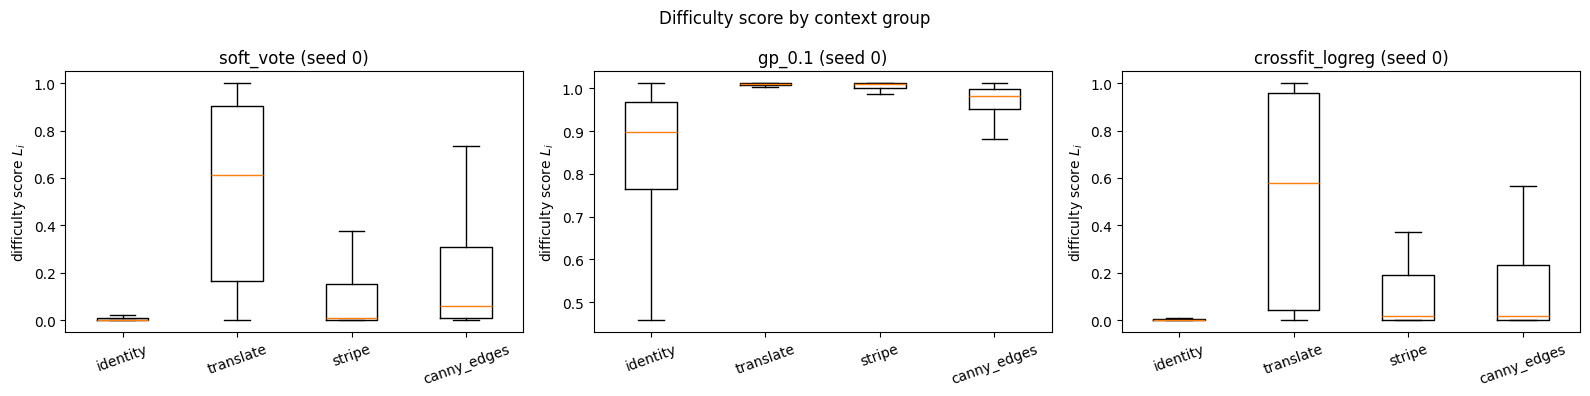

In [26]:
seed = SEEDS[0]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, score in zip(axes, ["soft_vote", GP_MAIN, "crossfit_logreg"]):
    plot_score_by_group(ax, SCORES[seed][score], SEED_DATA[seed]["ctx"]["g"], VERSIONS,
                        f"{score} (seed {seed})")
fig.suptitle("Difficulty score by context group")
plt.tight_layout()
plt.show()

**How to read this:** one box per group (clean first). A score that detects rarity puts the rare-corruption boxes above the clean box. Overlapping boxes mean a tail of high scores will also contain many clean points. Note the scales differ: `soft_vote` and `crossfit_logreg` are $1 - p$ in [0, 1], while the GP score is a negative log-likelihood.

In [27]:
diag_rows = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    # Sanity check 3: can the CNN features tell the corruptions apart? Class-balanced so that
    # always predicting "clean" (95% of points) cannot pass.
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    g_pred = cross_val_predict(LogisticRegression(class_weight="balanced", max_iter=2000),
                               d["X_ctx"], d["ctx"]["g"], cv=cv)
    # Bandwidth diagnostic: effective number of context points each test query averages over,
    # for the selected gamma and for the paper's median rule.
    _, _, W = kernel_head_proba(d["logK_test"], d["ctx"]["y"], N_CLASSES, return_weights=True)
    log_K_median = log_gaussian_kernel(d["X_test"], d["X_ctx"], d["gamma_median"])
    _, _, W_median = kernel_head_proba(log_K_median, d["ctx"]["y"], N_CLASSES, return_weights=True)
    diag_rows.append({"seed": seed, "gamma": d["gamma"], "gamma_median_rule": d["gamma_median"],
                      "corruption_balanced_accuracy": balanced_accuracy_score(d["ctx"]["g"], g_pred),
                      "effective_neighbours": float(np.median(weight_perplexity(W)[0])),
                      "effective_neighbours_median_rule": float(np.median(weight_perplexity(W_median)[0]))})
DIAG = pd.DataFrame(diag_rows)
display(DIAG.round(3))
detectability = DIAG["corruption_balanced_accuracy"].mean()
SANITY["3 corruption detectability"] = (f"pass ({detectability:.3f})" if detectability >= 0.8 else
                                        f"WARNING ({detectability:.3f} < 0.8)")
if detectability < 0.8:
    print(f"WARNING (check 3): the CNN features separate the corruption groups poorly "
          f"(balanced accuracy {detectability:.3f} < 0.8). A clean-trained CNN may partly ignore corruptions.")

,seed,gamma,gamma_median_rule,corruption_balanced_accuracy,effective_neighbours,effective_neighbours_median_rule
0,0,0.187,0.006,0.867,41.903,5645.249
1,1,0.186,0.006,0.862,42.095,5643.839
2,2,0.187,0.006,0.837,44.777,5641.246
3,3,0.187,0.006,0.873,45.180,5640.897
4,4,0.187,0.006,0.862,43.551,5647.116
5,5,0.186,0.006,0.835,44.203,5636.621
6,6,0.186,0.006,0.856,43.866,5638.943
7,7,0.186,0.006,0.864,43.760,5646.633
8,8,0.186,0.006,0.872,41.636,5632.131
9,9,0.186,0.006,0.849,42.315,5641.284


**How to read this:**
* `corruption_balanced_accuracy` (sanity check 3) is the 5-fold cross-validated balanced accuracy of predicting the group (clean or which corruption) from the CNN features. Chance is 1 / (R + 1). It is class-balanced because 95% of points are clean, so plain accuracy would pass by always predicting "clean". Below 0.8 means the features barely see the corruptions.
* `effective_neighbours` is the perplexity of the kernel weights (median over test points): the typical number of context points each prediction effectively averages over. `_median_rule` is the same for the paper's median-heuristic γ. Values near the context size (6,000) mean the bandwidth is so wide that predictions are close to the class prior; the selected γ should give a small neighbourhood.

## 1.3 Interventions

Every intervention is a deterministic multiplier vector $m$ on the **same** context (no resampling here):

| Intervention | Rule |
|---|---|
| `baseline` | $m = 1$ |
| `tail(τ, λ)` | $m_i = 1 + λ\,[L_i \ge Q_τ(L)]$ (Eq. D.2) |
| `random_tail(τ, λ)` | same size and λ, points chosen at random (control) |
| `prune(q)` / `prune_random(q)` | $m = 0$ for the top-q scores / for q·n random points |
| `pseudo_group_balance` | balance the cells class × [in τ = 0.95 tail] (group-label-free DFR analogue) |
| `oracle_balance` | balance the true groups (**uses group labels**) |
| `balanced_context_ref` | a separate context with 1,500 images per group (**uses group labels**) |
| `smooth(λ)`, `exponential(β)` | Eq. D.3 / D.4 on min–max normalised surprisal (probability-type scores only) |

The kernel head uses $m$ in Eq. 13. Logistic regression uses `sample_weight = m`, after dropping $m = 0$ and rescaling to mean 1. Every row is evaluated on the paired test set *and* on the validation set; the validation set is used only for choosing τ/λ.

In [28]:
t0 = time.time()
ROWS_A = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    y, g = d["ctx"]["y"], d["ctx"]["g"]
    targets = {"test": (d["test"]["y"], d["test"]["g"]), "val": (VAL_SET["y"], VAL_SET["g"])}
    kernels = {"test": d["logK_test"], "val": d["logK_val"]}
    balanced = evaluate_kernel({"test": d["logK_test_bal"], "val": d["logK_val_bal"]}, targets,
                               d["bal"]["y"], None, d["rho"])
    for score in ["soft_vote", GP_MAIN]:
        rng = np.random.default_rng([seed, 1])  # same random controls for every score
        for iv in table_a_interventions(SCORES[seed][score], y, g, score == "soft_vote", rng):
            results = evaluate_kernel(kernels, targets, y, iv["m"], d["rho"])
            add_rows(ROWS_A, results, seed=seed, predictor="kernel", score=score, **settings_of(iv))
        add_rows(ROWS_A, balanced, seed=seed, predictor="kernel", score=score,
                 intervention="balanced_context_ref")
    print(f"seed {seed}: kernel head done ({time.time() - t0:.0f}s)")

seed 0: kernel head done (54s)
seed 1: kernel head done (107s)
seed 2: kernel head done (161s)
seed 3: kernel head done (215s)
seed 4: kernel head done (268s)
seed 5: kernel head done (322s)
seed 6: kernel head done (376s)
seed 7: kernel head done (430s)
seed 8: kernel head done (484s)
seed 9: kernel head done (537s)


In [29]:
t0 = time.time()
for seed in SEEDS:
    d = SEED_DATA[seed]
    y, g = d["ctx"]["y"], d["ctx"]["g"]
    targets = {"test": (d["test"]["y"], d["test"]["g"]), "val": (VAL_SET["y"], VAL_SET["g"])}
    inputs = {"test": d["X_test"], "val": d["X_val"]}
    balanced = evaluate_logreg(d["X_bal"], d["bal"]["y"], None, inputs, targets, d["rho"])
    for score in ["crossfit_logreg", "soft_vote"]:
        rng = np.random.default_rng([seed, 1])
        for iv in table_a_interventions(SCORES[seed][score], y, g, True, rng):
            results = evaluate_logreg(d["X_ctx"], y, iv["m"], inputs, targets, d["rho"])
            add_rows(ROWS_A, results, seed=seed, predictor="logreg", score=score, **settings_of(iv))
        add_rows(ROWS_A, balanced, seed=seed, predictor="logreg", score=score,
                 intervention="balanced_context_ref")
    print(f"seed {seed}: logistic regression done ({time.time() - t0:.0f}s)")

seed 0: logistic regression done (25s)
seed 1: logistic regression done (50s)
seed 2: logistic regression done (76s)
seed 3: logistic regression done (102s)
seed 4: logistic regression done (128s)
seed 5: logistic regression done (154s)
seed 6: logistic regression done (180s)
seed 7: logistic regression done (205s)
seed 8: logistic regression done (231s)
seed 9: logistic regression done (258s)


**Secondary: the paper's median-heuristic bandwidth.** The kernel head is run again with γ = 1 / median squared distance (the paper's rule) for the baseline, the pre-registered tail and its random control, using the soft-vote score computed under that γ. Its rows are labelled `kernel_median_gamma`.

In [30]:
t0 = time.time()
MEDIAN_RULE_AUC = []
for seed in SEEDS:
    d = SEED_DATA[seed]
    y, g, gamma_m = d["ctx"]["y"], d["ctx"]["g"], d["gamma_median"]
    targets = {"test": (d["test"]["y"], d["test"]["g"]), "val": (VAL_SET["y"], VAL_SET["g"])}
    kernels = {"test": log_gaussian_kernel(d["X_test"], d["X_ctx"], gamma_m),
               "val": log_gaussian_kernel(d["X_val"], d["X_ctx"], gamma_m)}
    L = soft_vote_score(log_gaussian_kernel(d["X_ctx"], d["X_ctx"], gamma_m), y, RUN_LOG)
    MEDIAN_RULE_AUC.append({"seed": seed, "auc": detection_auc(L, g > 0)})
    m_tail = tail_multiplier(L, PRE_LAM, PRE_TAU)
    m_random = random_tail_multiplier(len(y), int(np.sum(m_tail > 1)), PRE_LAM, np.random.default_rng([seed, 2]))
    for iv in [dict(intervention="baseline", m=None),
               dict(intervention="tail", tau=PRE_TAU, lam=PRE_LAM, m=m_tail),
               dict(intervention="random_tail", tau=PRE_TAU, lam=PRE_LAM, m=m_random)]:
        results = evaluate_kernel(kernels, targets, y, iv["m"], d["rho"])
        add_rows(ROWS_A, results, seed=seed, predictor="kernel_median_gamma", score="soft_vote",
                 **settings_of(iv))
    print(f"seed {seed}: median-rule kernel head done ({time.time() - t0:.0f}s)")

seed 0: median-rule kernel head done (4s)
seed 1: median-rule kernel head done (8s)
seed 2: median-rule kernel head done (12s)
seed 3: median-rule kernel head done (16s)
seed 4: median-rule kernel head done (20s)
seed 5: median-rule kernel head done (24s)
seed 6: median-rule kernel head done (28s)
seed 7: median-rule kernel head done (32s)
seed 8: median-rule kernel head done (36s)
seed 9: median-rule kernel head done (40s)


## 1.4 Results

In [31]:
DF_A = pd.DataFrame(ROWS_A)
DF_A["condition"] = DF_A.apply(condition_name, axis=1)
TEST_A = DF_A[DF_A["eval_set"] == "test"]
SUMMARY_A = mean_and_se(TEST_A, ["predictor", "score", "condition"], METRICS + GROUP_METRICS)
PAIRS_A = [("kernel", "soft_vote", "main"), ("kernel", GP_MAIN, "secondary"),
           ("logreg", "crossfit_logreg", "main"), ("logreg", "soft_vote", "secondary")]
SELECTED = {}
for predictor, score, role in PAIRS_A:
    SELECTED[(predictor, score)] = select_on_validation(DF_A, predictor, score)
    tau_s, lam_s = SELECTED[(predictor, score)]
    print(f"\n=== {predictor} head, {score} score ({role}); validation-selected tail: "
          f"tau={tau_s:g}, lam={lam_s:g} (uses group labels) ===")
    main = table_a_main(SUMMARY_A, predictor, score, main_conditions(SELECTED[(predictor, score)]))
    display(mean_se_table(main, ["condition", "setting"], METRICS))


=== kernel head, soft_vote score (main); validation-selected tail: tau=0.95, lam=8 (uses group labels) ===


,condition,setting,worst_group,balanced_mean,context_mean,worst_cell,n_seeds
0,baseline,,0.590 ± 0.005,0.843 ± 0.002,0.976 ± 0.001,0.309 ± 0.016,10
1,"tail(0.95, 8)",pre-registered,0.615 ± 0.005,0.834 ± 0.003,0.971 ± 0.002,0.383 ± 0.010,10
2,"random_tail(0.95, 8)",control for pre-registered,0.585 ± 0.006,0.838 ± 0.002,0.975 ± 0.001,0.297 ± 0.015,10
3,"tail(0.95, 8)",validation-selected (uses group labels),0.615 ± 0.005,0.834 ± 0.003,0.971 ± 0.002,0.383 ± 0.010,10
4,"random_tail(0.95, 8)",control for validation-selected,0.585 ± 0.006,0.838 ± 0.002,0.975 ± 0.001,0.297 ± 0.015,10
5,prune(0.05),,0.516 ± 0.006,0.819 ± 0.002,0.973 ± 0.001,0.216 ± 0.010,10
6,prune_random(0.05),control,0.589 ± 0.005,0.841 ± 0.002,0.976 ± 0.001,0.309 ± 0.016,10
7,prune(0.1),,0.490 ± 0.006,0.809 ± 0.002,0.971 ± 0.001,0.205 ± 0.008,10
8,prune_random(0.1),control,0.583 ± 0.006,0.840 ± 0.002,0.976 ± 0.001,0.306 ± 0.016,10
9,pseudo_group_balance,group-label-free,0.600 ± 0.005,0.824 ± 0.003,0.962 ± 0.002,0.300 ± 0.015,10



=== kernel head, gp_0.1 score (secondary); validation-selected tail: tau=0.9, lam=20 (uses group labels) ===


,condition,setting,worst_group,balanced_mean,context_mean,worst_cell,n_seeds
0,baseline,,0.590 ± 0.005,0.843 ± 0.002,0.976 ± 0.001,0.309 ± 0.016,10
1,"tail(0.95, 8)",pre-registered,0.617 ± 0.005,0.842 ± 0.003,0.974 ± 0.001,0.339 ± 0.015,10
2,"random_tail(0.95, 8)",control for pre-registered,0.585 ± 0.006,0.838 ± 0.002,0.975 ± 0.001,0.297 ± 0.015,10
3,"tail(0.9, 20)",validation-selected (uses group labels),0.627 ± 0.006,0.838 ± 0.004,0.969 ± 0.002,0.403 ± 0.012,10
4,"random_tail(0.9, 20)",control for validation-selected,0.562 ± 0.006,0.828 ± 0.003,0.972 ± 0.001,0.306 ± 0.019,10
5,prune(0.05),,0.514 ± 0.006,0.804 ± 0.003,0.974 ± 0.001,0.207 ± 0.014,10
6,prune_random(0.05),control,0.589 ± 0.005,0.841 ± 0.002,0.976 ± 0.001,0.309 ± 0.016,10
7,prune(0.1),,0.498 ± 0.007,0.777 ± 0.003,0.971 ± 0.001,0.175 ± 0.018,10
8,prune_random(0.1),control,0.583 ± 0.006,0.840 ± 0.002,0.976 ± 0.001,0.306 ± 0.016,10
9,pseudo_group_balance,group-label-free,0.613 ± 0.005,0.836 ± 0.003,0.970 ± 0.002,0.312 ± 0.014,10



=== logreg head, crossfit_logreg score (main); validation-selected tail: tau=0.99, lam=2 (uses group labels) ===


,condition,setting,worst_group,balanced_mean,context_mean,worst_cell,n_seeds
0,baseline,,0.577 ± 0.005,0.832 ± 0.003,0.972 ± 0.001,0.317 ± 0.011,10
1,"tail(0.95, 8)",pre-registered,0.570 ± 0.005,0.815 ± 0.003,0.965 ± 0.002,0.302 ± 0.022,10
2,"random_tail(0.95, 8)",control for pre-registered,0.573 ± 0.005,0.830 ± 0.003,0.974 ± 0.001,0.317 ± 0.012,10
3,"tail(0.99, 2)",validation-selected (uses group labels),0.573 ± 0.005,0.825 ± 0.003,0.971 ± 0.001,0.305 ± 0.017,10
4,"random_tail(0.99, 2)",control for validation-selected,0.576 ± 0.006,0.832 ± 0.003,0.972 ± 0.001,0.320 ± 0.012,10
5,prune(0.05),,0.499 ± 0.006,0.812 ± 0.003,0.973 ± 0.001,0.220 ± 0.014,10
6,prune_random(0.05),control,0.575 ± 0.006,0.831 ± 0.003,0.973 ± 0.001,0.322 ± 0.013,10
7,prune(0.1),,0.484 ± 0.004,0.803 ± 0.002,0.972 ± 0.001,0.182 ± 0.010,10
8,prune_random(0.1),control,0.575 ± 0.007,0.829 ± 0.003,0.973 ± 0.001,0.310 ± 0.012,10
9,pseudo_group_balance,group-label-free,0.563 ± 0.004,0.809 ± 0.003,0.961 ± 0.002,0.285 ± 0.024,10



=== logreg head, soft_vote score (secondary); validation-selected tail: tau=0.8, lam=2 (uses group labels) ===


,condition,setting,worst_group,balanced_mean,context_mean,worst_cell,n_seeds
0,baseline,,0.577 ± 0.005,0.832 ± 0.003,0.972 ± 0.001,0.317 ± 0.011,10
1,"tail(0.95, 8)",pre-registered,0.560 ± 0.006,0.805 ± 0.004,0.963 ± 0.002,0.292 ± 0.023,10
2,"random_tail(0.95, 8)",control for pre-registered,0.573 ± 0.005,0.830 ± 0.003,0.974 ± 0.001,0.317 ± 0.012,10
3,"tail(0.8, 2)",validation-selected (uses group labels),0.579 ± 0.006,0.828 ± 0.003,0.970 ± 0.001,0.313 ± 0.017,10
4,"random_tail(0.8, 2)",control for validation-selected,0.570 ± 0.006,0.829 ± 0.003,0.973 ± 0.001,0.310 ± 0.012,10
5,prune(0.05),,0.495 ± 0.007,0.814 ± 0.002,0.973 ± 0.001,0.191 ± 0.011,10
6,prune_random(0.05),control,0.575 ± 0.006,0.831 ± 0.003,0.973 ± 0.001,0.322 ± 0.013,10
7,prune(0.1),,0.472 ± 0.005,0.805 ± 0.002,0.971 ± 0.001,0.159 ± 0.013,10
8,prune_random(0.1),control,0.575 ± 0.007,0.829 ± 0.003,0.973 ± 0.001,0.310 ± 0.012,10
9,pseudo_group_balance,group-label-free,0.553 ± 0.006,0.797 ± 0.004,0.958 ± 0.003,0.281 ± 0.022,10


**How to read this:** one table per predictor/score pair. Values are mean ± SE over seeds on the 4,000-image paired test set.
* `worst_group`: the lowest accuracy among the R + 1 groups.
* `balanced_mean`: the average of the group accuracies.
* `context_mean`: $(1-ρ)\,\text{acc}_\text{clean} + ρ\cdot\text{mean(acc}_\text{rare})$, the accuracy expected if test data looked like the context.
* `worst_cell`: the lowest class × group accuracy.

A useful intervention raises `worst_group` above both `baseline` and its *random control* without a large drop in `context_mean`.
* `setting` says how τ/λ were chosen. **Validation-selected rows use group labels** and are not group-label-free.
* Pruning removes the hardest points, which in this design are mostly *valid* rare examples, so it should not be read as "cleaning".
* SEs from few seeds are rough; the paired differences below are the better comparison.

In [32]:
for metric in ["worst_group", "balanced_mean"]:
    diffs = paired_differences(TEST_A, metric, "baseline", ["predictor", "score"], ["condition"])
    print(f"\nPaired per-seed difference vs baseline: {metric} (mean ± SE over seeds)")
    for predictor, score, role in PAIRS_A:
        wanted = []  # main conditions in display order, each once
        for condition, _ in main_conditions(SELECTED[(predictor, score)]):
            if condition != "baseline" and condition not in wanted:
                wanted.append(condition)
        rows = diffs[(diffs.predictor == predictor) & (diffs.score == score) & diffs.condition.isin(wanted)]
        rows = rows.set_index("condition").loc[[c for c in wanted if c in set(rows.condition)]].reset_index()
        print(f"--- {predictor} / {score} ({role})")
        display(mean_se_table(rows, ["condition"], ["diff"]))


Paired per-seed difference vs baseline: worst_group (mean ± SE over seeds)
--- kernel / soft_vote (main)


,condition,diff,n_seeds
0,"tail(0.95, 8)",0.025 ± 0.004,10
1,"random_tail(0.95, 8)",-0.005 ± 0.002,10
2,prune(0.05),-0.075 ± 0.003,10
3,prune_random(0.05),-0.002 ± 0.000,10
4,prune(0.1),-0.101 ± 0.003,10
5,prune_random(0.1),-0.007 ± 0.001,10
6,pseudo_group_balance,0.010 ± 0.004,10
7,oracle_balance,0.040 ± 0.006,10
8,balanced_context_ref,0.242 ± 0.006,10
9,smooth(10),0.014 ± 0.002,10


--- kernel / gp_0.1 (secondary)


,condition,diff,n_seeds
0,"tail(0.95, 8)",0.027 ± 0.003,10
1,"random_tail(0.95, 8)",-0.005 ± 0.002,10
2,"tail(0.9, 20)",0.037 ± 0.005,10
3,"random_tail(0.9, 20)",-0.028 ± 0.003,10
4,prune(0.05),-0.076 ± 0.002,10
5,prune_random(0.05),-0.002 ± 0.000,10
6,prune(0.1),-0.093 ± 0.004,10
7,prune_random(0.1),-0.007 ± 0.001,10
8,pseudo_group_balance,0.023 ± 0.004,10
9,oracle_balance,0.040 ± 0.006,10


--- logreg / crossfit_logreg (main)


...

,condition,diff,n_seeds
0,"tail(0.95, 8)",-0.001 ± 0.001,10
1,"random_tail(0.95, 8)",-0.005 ± 0.001,10
2,"tail(0.9, 20)",-0.004 ± 0.002,10
3,"random_tail(0.9, 20)",-0.015 ± 0.001,10
4,prune(0.05),-0.038 ± 0.003,10
5,prune_random(0.05),-0.002 ± 0.000,10
6,prune(0.1),-0.066 ± 0.003,10
7,prune_random(0.1),-0.002 ± 0.001,10
8,pseudo_group_balance,-0.007 ± 0.002,10
9,oracle_balance,0.015 ± 0.002,10


--- logreg / crossfit_logreg (main)


,condition,diff,n_seeds
0,"tail(0.95, 8)",-0.016 ± 0.002,10
1,"random_tail(0.95, 8)",-0.002 ± 0.001,10
2,"tail(0.99, 2)",-0.007 ± 0.001,10
3,"random_tail(0.99, 2)",-0.000 ± 0.000,10
4,prune(0.05),-0.020 ± 0.002,10
5,prune_random(0.05),-0.001 ± 0.001,10
6,prune(0.1),-0.029 ± 0.002,10
7,prune_random(0.1),-0.003 ± 0.001,10
8,pseudo_group_balance,-0.023 ± 0.002,10
9,oracle_balance,0.019 ± 0.002,10


--- logreg / soft_vote (secondary)


,condition,diff,n_seeds
0,"tail(0.95, 8)",-0.027 ± 0.002,10
1,"random_tail(0.95, 8)",-0.002 ± 0.001,10
2,"tail(0.8, 2)",-0.003 ± 0.001,10
3,"random_tail(0.8, 2)",-0.002 ± 0.001,10
4,prune(0.05),-0.018 ± 0.001,10
5,prune_random(0.05),-0.001 ± 0.001,10
6,prune(0.1),-0.026 ± 0.002,10
7,prune_random(0.1),-0.003 ± 0.001,10
8,pseudo_group_balance,-0.035 ± 0.002,10
9,oracle_balance,0.019 ± 0.002,10


**How to read this:** for every seed, the condition's accuracy minus the baseline's accuracy on the same context and test set, then mean ± SE over seeds. Pairing removes the seed-to-seed variation that both rows share.
* A difference whose mean is more than about 2 SE above 0 is a consistent improvement; one more than about 2 SE below 0 is a consistent loss.
* Compare each tail rule with its random control: if both move by similar amounts, the score is not what drives the change.

In [33]:
print("Full Table A grid (test set, mean ± SE over seeds):")
display(mean_se_table(SUMMARY_A, ["predictor", "score", "condition"], METRICS))

Full Table A grid (test set, mean ± SE over seeds):


,predictor,score,condition,worst_group,balanced_mean,context_mean,worst_cell,n_seeds
0,kernel,gp_0.1,balanced_context_ref,0.833 ± 0.003,0.928 ± 0.001,0.967 ± 0.002,0.628 ± 0.014,10
1,kernel,gp_0.1,baseline,0.590 ± 0.005,0.843 ± 0.002,0.976 ± 0.001,0.309 ± 0.016,10
2,kernel,gp_0.1,oracle_balance,0.631 ± 0.006,0.858 ± 0.003,0.959 ± 0.002,0.331 ± 0.022,10
3,kernel,gp_0.1,prune(0.05),0.514 ± 0.006,0.804 ± 0.003,0.974 ± 0.001,0.207 ± 0.014,10
4,kernel,gp_0.1,prune(0.1),0.498 ± 0.007,0.777 ± 0.003,0.971 ± 0.001,0.175 ± 0.018,10
5,kernel,gp_0.1,prune_random(0.05),0.589 ± 0.005,0.841 ± 0.002,0.976 ± 0.001,0.309 ± 0.016,10
6,kernel,gp_0.1,prune_random(0.1),0.583 ± 0.006,0.840 ± 0.002,0.976 ± 0.001,0.306 ± 0.016,10
7,kernel,gp_0.1,pseudo_group_balance,0.613 ± 0.005,0.836 ± 0.003,0.970 ± 0.002,0.312 ± 0.014,10
8,kernel,gp_0.1,"random_tail(0.8, 2)",0.585 ± 0.007,0.839 ± 0.002,0.975 ± 0.002,0.302 ± 0.016,10
9,kernel,gp_0.1,"random_tail(0.8, 20)",0.557 ± 0.007,0.823 ± 0.003,0.972 ± 0.001,0.287 ± 0.015,10


In [34]:
print("Secondary: kernel head with the paper's median-heuristic bandwidth (soft-vote score), test set")
median_rows = SUMMARY_A[SUMMARY_A.predictor == "kernel_median_gamma"]
display(mean_se_table(median_rows, ["condition"], METRICS))
auc = pd.DataFrame(MEDIAN_RULE_AUC)["auc"]
print(f"soft-vote detection AUC under the median rule: {auc.mean():.3f} ± {auc.std(ddof=1) / np.sqrt(len(auc)):.3f}")

Secondary: kernel head with the paper's median-heuristic bandwidth (soft-vote score), test set


,condition,worst_group,balanced_mean,context_mean,worst_cell,n_seeds
0,baseline,0.433 ± 0.004,0.753 ± 0.002,0.953 ± 0.002,0.145 ± 0.009,10
1,"random_tail(0.95, 8)",0.424 ± 0.009,0.745 ± 0.006,0.949 ± 0.004,0.133 ± 0.014,10
2,"tail(0.95, 8)",0.267 ± 0.015,0.473 ± 0.015,0.707 ± 0.022,0.000 ± 0.000,10


soft-vote detection AUC under the median rule: 0.802 ± 0.003


**How to read this:** the same three conditions as the main kernel-head table, but with the paper's median-heuristic γ. Compare `baseline` here with the main table's baseline to see how much the bandwidth alone changes the kernel head. Also compare the detection AUC with the `soft_vote` row of 1.2: a wider kernel can make the score better at flagging rare points even while the predictor gets worse, which is the paper's point that detection and intervention value are different questions.

## 1.5 Figures

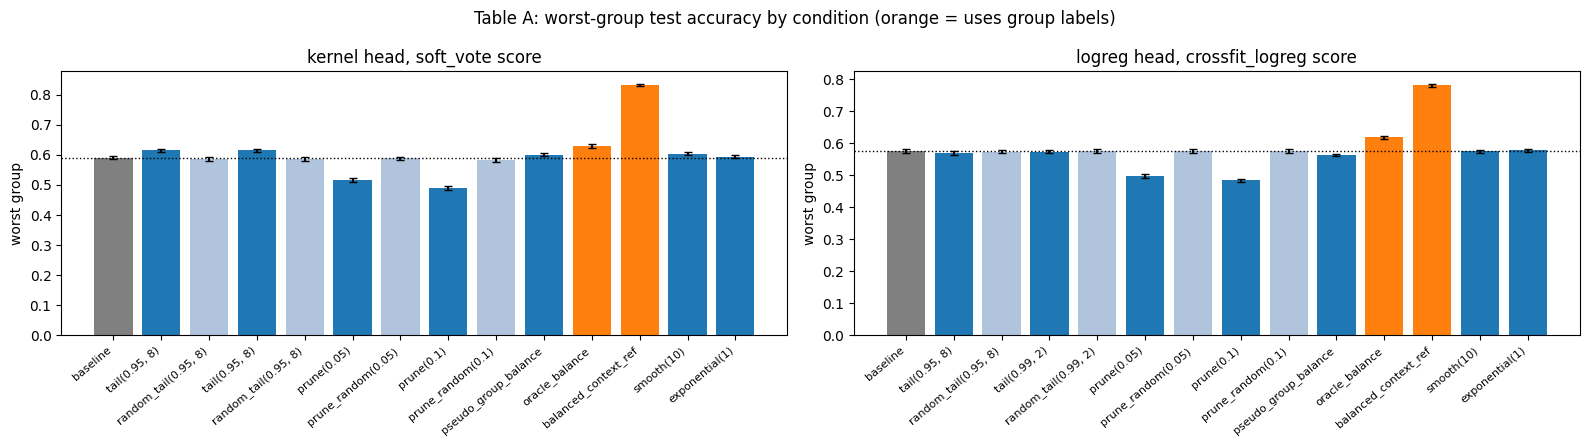

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, (predictor, score) in zip(axes, [("kernel", "soft_vote"), ("logreg", "crossfit_logreg")]):
    main = table_a_main(SUMMARY_A, predictor, score, main_conditions(SELECTED[(predictor, score)]))
    plot_condition_bars(ax, main, "worst_group", f"{predictor} head, {score} score")
fig.suptitle("Table A: worst-group test accuracy by condition (orange = uses group labels)")
plt.tight_layout()
plt.show()

**How to read this:** bar height is the mean worst-group test accuracy over seeds and the error bar is ±1 SE. The dotted line is the baseline. Blue bars are score-based rules, light blue their random controls, and orange the references that use group labels (oracle balance, balanced context).

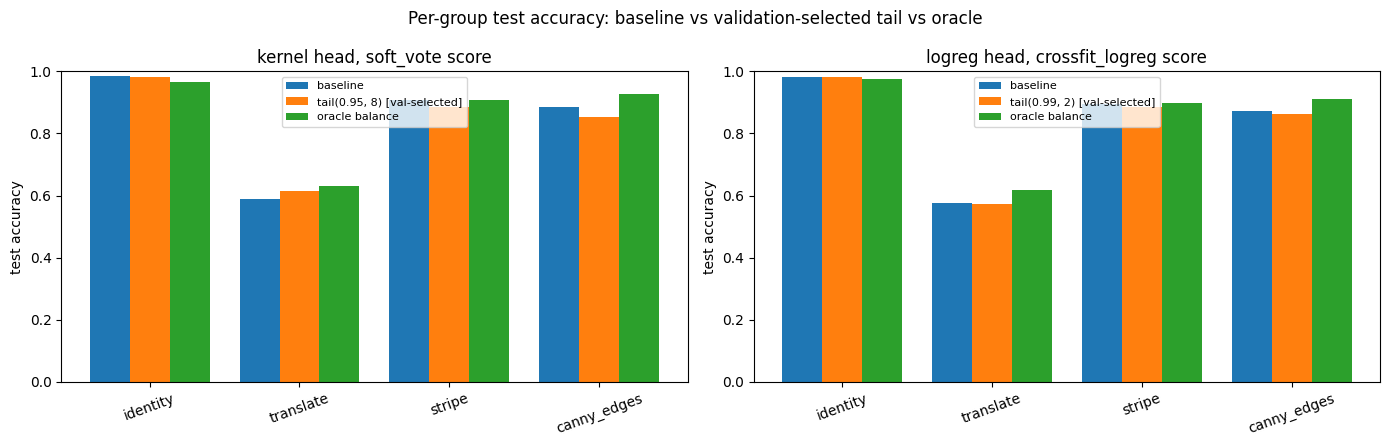

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (predictor, score) in zip(axes, [("kernel", "soft_vote"), ("logreg", "crossfit_logreg")]):
    tau_s, lam_s = SELECTED[(predictor, score)]
    picked = table_a_main(SUMMARY_A, predictor, score,
                          [("baseline", ""), (f"tail({tau_s:g}, {lam_s:g})", ""), ("oracle_balance", "")])
    labels = ["baseline", f"tail({tau_s:g}, {lam_s:g}) [val-selected]", "oracle balance"]
    plot_group_accuracies(ax, [row for _, row in picked.iterrows()], labels, VERSIONS,
                          f"{predictor} head, {score} score")
fig.suptitle("Per-group test accuracy: baseline vs validation-selected tail vs oracle")
plt.tight_layout()
plt.show()

**How to read this:** for each group on the x-axis, the three bars compare the baseline, the tail rule chosen on the *validation* set, and the group-label oracle. Gains on the rare groups that come with a large loss on `identity` show a trade-off rather than a free improvement.

## 1.6 Standard errors and baseline gap (sanity check 4)

In [37]:
n_group = TEST_PER_CLASS * N_CLASSES
gap_ok = False
for predictor in ["kernel", "logreg"]:
    base = SUMMARY_A[(SUMMARY_A.predictor == predictor) & (SUMMARY_A.condition == "baseline")].iloc[0]
    p, gap = base["worst_group_mean"], base["acc_g0_mean"] - base["worst_group_mean"]
    gap_ok = gap_ok or gap >= 0.10
    print(f"[stats] {predictor}: each test group has {n_group} images, so the binomial SE of one "
          f"seed's worst-group accuracy near {p:.2f} is about {np.sqrt(p * (1 - p) / n_group):.3f}. "
          f"Baseline gap clean - worst = {gap:.3f}.")
SANITY["4 baseline gap >= 0.10"] = "pass" if gap_ok else "WARNING (gap < 0.10 for both predictors)"
if not gap_ok:
    print("WARNING (check 4): clean minus worst-group accuracy is below 0.10 for both predictors, so the "
          "rare groups are barely harder and this experiment is uninformative. Options (not applied): "
          "harsher corruptions (lower PILOT_MIN_ACC) or a lower RHO.")

[stats] kernel: each test group has 1000 images, so the binomial SE of one seed's worst-group accuracy near 0.59 is about 0.016. Baseline gap clean - worst = 0.395.
[stats] logreg: each test group has 1000 images, so the binomial SE of one seed's worst-group accuracy near 0.58 is about 0.016. Baseline gap clean - worst = 0.406.


# 2. Table B: what the selected tail contains

Mirrors paper Table D.2. Uses the scores computed in 1.1.

For each τ, the tail is $\{i : L_i \ge Q_\tau(L)\}$.
* **precision** is the fraction of the tail that is rare;
* **recall** is the fraction of all rare points that are in the tail;
* `n_<corruption>` counts the tail points from each rare corruption;
* `tail_size` is the realised size (ties can change it).

## 2.1 Tail composition

In [38]:
comp_rows = []
for seed in SEEDS:
    g = SEED_DATA[seed]["ctx"]["g"]
    for score, L in SCORES[seed].items():
        for tau in TAUS:
            row = tail_composition(L, g, tau, R + 1)
            comp_rows.append({"seed": seed, "score": score, **row, "auc": detection_auc(L, g > 0)})
TABLE_B = pd.DataFrame(comp_rows)
count_cols = [f"n_g{k}" for k in range(1, R + 1)]
summary_b = mean_and_se(TABLE_B, ["score", "tau"], ["tail_size", "precision", "recall", "auc"] + count_cols)
table_b = mean_se_table(summary_b, ["score", "tau"], ["tail_size", "precision", "recall", "auc"] + count_cols)
display(table_b.rename(columns={f"n_g{k}": f"n_{VERSIONS[k]}" for k in range(1, R + 1)}))

,score,tau,tail_size,precision,recall,auc,n_translate,n_stripe,n_canny_edges,n_seeds
0,crossfit_logreg,0.80,1200.000 ± 0.000,0.170 ± 0.003,0.679 ± 0.010,0.832 ± 0.004,85.800 ± 0.841,56.800 ± 2.380,61.200 ± 1.724,10
1,crossfit_logreg,0.90,600.000 ± 0.000,0.244 ± 0.005,0.488 ± 0.010,0.832 ± 0.004,71.100 ± 0.752,35.000 ± 1.726,40.200 ± 1.867,10
2,crossfit_logreg,0.95,300.000 ± 0.000,0.321 ± 0.004,0.321 ± 0.004,0.832 ± 0.004,55.800 ± 0.952,19.200 ± 1.263,21.200 ± 0.490,10
3,crossfit_logreg,0.97,180.000 ± 0.000,0.384 ± 0.007,0.231 ± 0.004,0.832 ± 0.004,45.200 ± 1.245,11.400 ± 1.157,12.600 ± 0.833,10
4,crossfit_logreg,0.99,60.000 ± 0.000,0.517 ± 0.015,0.103 ± 0.003,0.832 ± 0.004,23.500 ± 1.035,3.900 ± 0.781,3.600 ± 0.452,10
5,gp_0.01,0.80,1200.000 ± 0.000,0.189 ± 0.001,0.757 ± 0.006,0.871 ± 0.003,92.400 ± 0.833,85.300 ± 1.023,49.300 ± 1.291,10
6,gp_0.01,0.90,600.000 ± 0.000,0.296 ± 0.005,0.593 ± 0.010,0.871 ± 0.003,82.300 ± 1.165,72.400 ± 1.845,23.200 ± 1.775,10
7,gp_0.01,0.95,300.000 ± 0.000,0.430 ± 0.006,0.430 ± 0.006,0.871 ± 0.003,64.100 ± 1.524,54.100 ± 2.057,10.800 ± 1.009,10
8,gp_0.01,0.97,180.000 ± 0.000,0.516 ± 0.012,0.310 ± 0.007,0.871 ± 0.003,49.900 ± 1.278,38.200 ± 1.879,4.800 ± 0.554,10
9,gp_0.01,0.99,60.000 ± 0.000,0.680 ± 0.015,0.136 ± 0.003,0.871 ± 0.003,23.200 ± 1.052,16.500 ± 0.601,1.100 ± 0.348,10


**How to read this:** the context has 300 rare points out of 6,000 (5%), so a tail at τ = 0.95 has room for about all of them.
* High precision at a given τ means upweighting that tail mostly upweights rare points.
* Low precision means it mostly upweights hard *clean* points (e.g. badly written digits).
* The per-corruption counts show whether the score finds every corruption or only some.

This mirrors the paper's point that a high AUC can coexist with a tail dominated by majority points.

## 2.2 Clean images in the tail

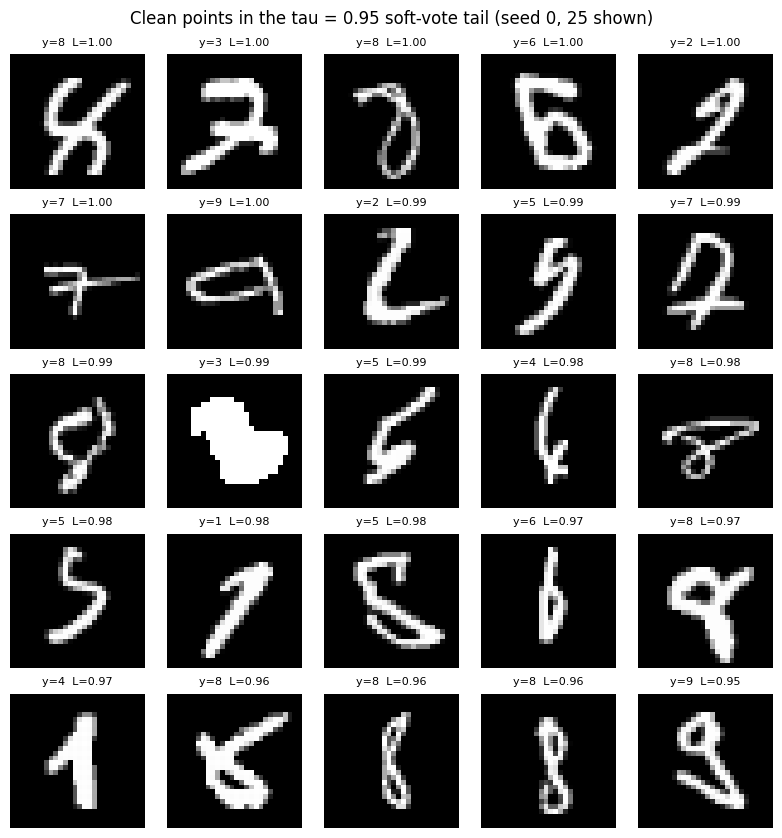

In [39]:
seed = SEEDS[0]
d = SEED_DATA[seed]
L = SCORES[seed]["soft_vote"]
clean_tail = np.where((L >= np.quantile(L, 0.95)) & (d["ctx"]["g"] == 0))[0]
clean_tail = clean_tail[np.argsort(-L[clean_tail])][:25]
images = mnist_c.gather_images(MNIST_C_ROOT, "train", d["ctx"]["idx"][clean_tail], d["ctx"]["version"][clean_tail])
fig, axes = plt.subplots(5, 5, figsize=(8, 8.5))
for k, ax in enumerate(axes.ravel()):
    ax.axis("off")
    if k < len(clean_tail):
        ax.imshow(images[k], cmap="gray")
        ax.set_title(f"y={d['ctx']['y'][clean_tail[k]]}  L={L[clean_tail[k]]:.2f}", fontsize=8)
fig.suptitle(f"Clean points in the tau = 0.95 soft-vote tail (seed {seed}, {len(clean_tail)} shown)")
plt.tight_layout()
plt.show()

**How to read this:** these are *clean* context images that the soft-vote score ranks among the top 5% hardest, sorted by score. Look at what makes them hard: ambiguous handwriting, unusual stroke width, possible label errors. Upweighting them is what a tail rule does besides upweighting the rare corruptions.

# 3. ρ sweep: how rare is too rare?

The same design at rare fractions ρ ∈ {0.01, 0.025, 0.05, 0.10}, with rare images per digit per corruption = max(1, round(600·ρ/R)). Each (seed, ρ) draws its **own** context, scaler and γ; the test set is the seed's paired test set.

Only four conditions are run: baseline, the pre-registered tail (τ = 0.95, λ = 8), its random control, and the oracle balance. Each predictor uses its main score (kernel head: soft-vote; logistic regression: cross-fitted).

## 3.1 Run and tables

In [40]:
t0 = time.time()
assert all(seed in SEED_DATA for seed in SEEDS), "run Section 0 first"
ROWS_RHO = []
for seed in SEEDS:
    for rho in RHOS:
        ROWS_RHO += run_rho_context(seed, rho, CNN, MNIST_C_ROOT, SPLITS, LABELS, VERSIONS,
                                    SEED_DATA[seed], RUN_LOG)
    print(f"seed {seed}: rho sweep done ({time.time() - t0:.0f}s)")
DF_RHO = pd.DataFrame(ROWS_RHO)
base_rho = DF_RHO[DF_RHO.intervention == "baseline"]
print("DIAGNOSTIC: detection AUC (rare vs clean) and realised rho")
display(mean_se_table(mean_and_se(base_rho, ["predictor", "rho"], ["rho_realised", "detection_auc"]),
                      ["predictor", "rho"], ["rho_realised", "detection_auc"]))
SUMMARY_RHO = mean_and_se(DF_RHO, ["predictor", "rho", "intervention"], METRICS)
display(mean_se_table(SUMMARY_RHO, ["predictor", "rho", "intervention"], METRICS))

seed 0: rho sweep done (95s)
seed 1: rho sweep done (191s)
seed 2: rho sweep done (286s)
seed 3: rho sweep done (381s)
seed 4: rho sweep done (476s)
seed 5: rho sweep done (571s)
seed 6: rho sweep done (666s)
seed 7: rho sweep done (761s)
seed 8: rho sweep done (856s)
seed 9: rho sweep done (950s)
DIAGNOSTIC: detection AUC (rare vs clean) and realised rho


,predictor,rho,rho_realised,detection_auc,n_seeds
0,kernel,0.010,0.010 ± 0.000,0.827 ± 0.011,10
1,kernel,0.025,0.025 ± 0.000,0.805 ± 0.006,10
2,kernel,0.050,0.050 ± 0.000,0.809 ± 0.004,10
3,kernel,0.100,0.100 ± 0.000,0.799 ± 0.005,10
4,logreg,0.010,0.010 ± 0.000,0.848 ± 0.007,10
5,logreg,0.025,0.025 ± 0.000,0.844 ± 0.005,10
6,logreg,0.050,0.050 ± 0.000,0.829 ± 0.003,10
7,logreg,0.100,0.100 ± 0.000,0.818 ± 0.003,10


,predictor,rho,intervention,worst_group,balanced_mean,context_mean,worst_cell,n_seeds
0,kernel,0.010,baseline,0.515 ± 0.006,0.793 ± 0.003,0.983 ± 0.001,0.217 ± 0.017,10
1,kernel,0.010,oracle_balance,0.512 ± 0.006,0.794 ± 0.004,0.964 ± 0.002,0.225 ± 0.013,10
2,kernel,0.010,random_tail,0.512 ± 0.006,0.791 ± 0.003,0.981 ± 0.001,0.204 ± 0.012,10
3,kernel,0.010,tail,0.521 ± 0.006,0.776 ± 0.003,0.979 ± 0.002,0.233 ± 0.014,10
4,kernel,0.025,baseline,0.543 ± 0.006,0.817 ± 0.002,0.980 ± 0.002,0.255 ± 0.013,10
5,kernel,0.025,oracle_balance,0.560 ± 0.008,0.825 ± 0.003,0.959 ± 0.002,0.247 ± 0.019,10
6,kernel,0.025,random_tail,0.541 ± 0.007,0.814 ± 0.002,0.979 ± 0.002,0.253 ± 0.015,10
7,kernel,0.025,tail,0.553 ± 0.006,0.807 ± 0.002,0.977 ± 0.001,0.313 ± 0.014,10
8,kernel,0.050,baseline,0.585 ± 0.007,0.841 ± 0.003,0.976 ± 0.001,0.312 ± 0.010,10
9,kernel,0.050,oracle_balance,0.625 ± 0.008,0.857 ± 0.003,0.957 ± 0.002,0.336 ± 0.015,10


**How to read this:**
* The first table shows how well each predictor's score detects rare points at each ρ. `rho_realised` can differ from ρ because of rounding.
* The second table shows test accuracy per condition.
* As ρ shrinks, the rare groups have fewer examples to learn from. Watch whether the baseline worst-group accuracy falls, and whether the tail rule's gain over its random control grows or shrinks.

## 3.2 Figure

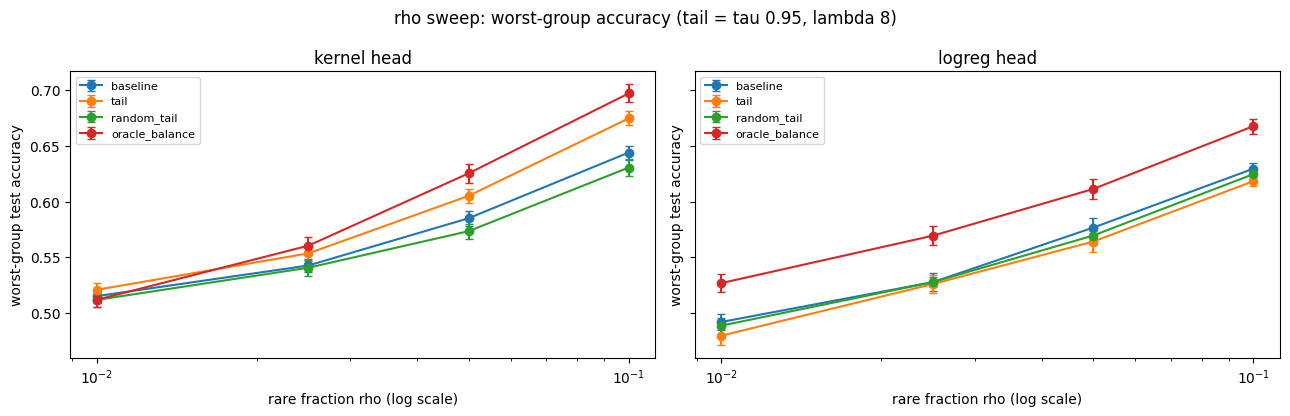

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, predictor in zip(axes, ["kernel", "logreg"]):
    for intervention in ["baseline", "tail", "random_tail", "oracle_balance"]:
        rows = SUMMARY_RHO[(SUMMARY_RHO.predictor == predictor) & (SUMMARY_RHO.intervention == intervention)]
        rows = rows.sort_values("rho")
        ax.errorbar(rows["rho"], rows["worst_group_mean"], yerr=rows["worst_group_se"],
                    marker="o", capsize=3, label=intervention)
    ax.set_xscale("log")
    ax.set_xlabel("rare fraction rho (log scale)")
    ax.set_ylabel("worst-group test accuracy")
    ax.set_title(f"{predictor} head")
    ax.legend(fontsize=8)
fig.suptitle(f"rho sweep: worst-group accuracy (tail = tau {PRE_TAU:g}, lambda {PRE_LAM:g})")
plt.tight_layout()
plt.show()

**How to read this:** each line is one condition and each point is the mean over seeds (±1 SE) at one ρ. The vertical gap between `tail` and `random_tail` at a given ρ is the part of the tail rule's effect that comes from *which* points the score selects.

# 4. Table C: label noise

Mirrors paper Table 3 / D.5.

On each seed's rare-corruption context, a uniformly random fraction η of labels is flipped, **independent of group**. Test labels stay clean.
* **Symmetric** noise (main): the new label is uniform over the other 9 classes.
* **Asymmetric** noise (secondary): 1↔7, 3↔8, 4↔9, 5↔6, 2→7, 0→6.

Both scores are recomputed on the noisy labels. Each row below is one edited context, and all three predictors (kernel head, 1-NN, logistic regression) use **the same** edited context:

| Row | Edit |
|---|---|
| `clean_label_ref` | the same context with no flips (reference) |
| `noisy_baseline` | noisy labels, no edit |
| `prune_top_q` | remove the top q = η by score (soft-vote main, GP secondary) |
| `prune_random_q` | remove q·n random points (control) |
| `oracle_drop_flipped` | remove exactly the flipped points (uses the noise mask) |
| `relabel_top_q` | replace the top-q labels by the frozen LOO soft-vote prediction |

This runs with the full 128-d CNN features and with PCA(10) of them, fitted on the context. That is the analogue of the paper's 2-D vs 20-D comparison, and the only place PCA is used.

## 4.1 Run

In [42]:
t0 = time.time()
assert all(seed in SEED_DATA for seed in SEEDS), "run Section 0 first"
ROWS_C, AUC_C, COMP_C = [], [], []
for seed in SEEDS:
    d = SEED_DATA[seed]
    for dim in [d["X_ctx"].shape[1], LOW_DIM]:
        inputs = table_c_inputs(d, dim, seed, RUN_LOG)
        for noise in NOISE_TYPES:
            for eta in ETAS:
                rows, aucs, comps = run_noise_setting(seed, dim, noise, eta, inputs, d, VERSIONS)
                ROWS_C += rows
                AUC_C += aucs
                COMP_C += comps
    print(f"seed {seed}: Table C done ({time.time() - t0:.0f}s)")
DF_C, DF_AUC_C, DF_COMP_C = pd.DataFrame(ROWS_C), pd.DataFrame(AUC_C), pd.DataFrame(COMP_C)

seed 0: Table C done (85s)
seed 1: Table C done (168s)
seed 2: Table C done (252s)
seed 3: Table C done (334s)
seed 4: Table C done (419s)
seed 5: Table C done (502s)
seed 6: Table C done (586s)
seed 7: Table C done (669s)
seed 8: Table C done (752s)
seed 9: Table C done (837s)


## 4.2 Detection of flipped labels

In [43]:
print("DIAGNOSTIC: detection AUC of each score for flipped vs unflipped labels, overall and per group")
summary_auc_c = mean_and_se(DF_AUC_C, ["dim", "noise", "eta", "score", "group"], ["auc"])
display(mean_se_table(summary_auc_c, ["dim", "noise", "eta", "score", "group"], ["auc"]))

DIAGNOSTIC: detection AUC of each score for flipped vs unflipped labels, overall and per group


,dim,noise,eta,score,group,auc,n_seeds
0,10,asymmetric,0.2,gp,all,0.604 ± 0.004,10
1,10,asymmetric,0.2,gp,canny_edges,0.617 ± 0.038,10
2,10,asymmetric,0.2,gp,identity,0.612 ± 0.003,10
3,10,asymmetric,0.2,gp,stripe,0.609 ± 0.019,10
4,10,asymmetric,0.2,gp,translate,0.531 ± 0.029,10
5,10,asymmetric,0.2,soft_vote,all,0.978 ± 0.001,10
6,10,asymmetric,0.2,soft_vote,canny_edges,0.922 ± 0.012,10
7,10,asymmetric,0.2,soft_vote,identity,0.988 ± 0.000,10
8,10,asymmetric,0.2,soft_vote,stripe,0.903 ± 0.014,10
9,10,asymmetric,0.2,soft_vote,translate,0.704 ± 0.021,10


**How to read this:** AUC of each score for picking out flipped labels. `group = all` uses every context point; the other rows use only the points of one group. Per-group AUCs show whether noise is harder to detect among rare-corruption images than among clean ones. Compare `dim` 128 vs 10 and soft-vote vs GP, as in the paper's Table 3.

## 4.3 Accuracy after each edit

In [44]:
SUMMARY_C = mean_and_se(DF_C, ["dim", "noise", "eta", "predictor", "intervention", "score"],
                        ["context_mean", "balanced_mean", "worst_group"])
for noise in NOISE_TYPES:
    for eta in ETAS:
        print(f"\n=== {noise} noise, eta = {eta:g} (test accuracy, mean ± SE over seeds) ===")
        block = SUMMARY_C[(SUMMARY_C.noise == noise) & (SUMMARY_C.eta == eta)]
        display(mean_se_table(block, ["dim", "predictor", "intervention", "score"],
                              ["context_mean", "balanced_mean", "worst_group"]))


=== symmetric noise, eta = 0.2 (test accuracy, mean ± SE over seeds) ===


,dim,predictor,intervention,score,context_mean,balanced_mean,worst_group,n_seeds
0,10,1nn,clean_label_ref,none,0.966 ± 0.002,0.815 ± 0.003,0.554 ± 0.007,10
1,10,1nn,noisy_baseline,none,0.773 ± 0.004,0.660 ± 0.004,0.427 ± 0.008,10
2,10,1nn,oracle_drop_flipped,none,0.966 ± 0.002,0.807 ± 0.002,0.532 ± 0.008,10
3,10,1nn,prune_random_q,none,0.769 ± 0.005,0.654 ± 0.004,0.420 ± 0.009,10
4,10,1nn,prune_top_q,gp,0.792 ± 0.005,0.633 ± 0.004,0.395 ± 0.006,10
5,10,1nn,prune_top_q,soft_vote,0.962 ± 0.002,0.795 ± 0.003,0.504 ± 0.011,10
6,10,1nn,relabel_top_q,gp,0.807 ± 0.004,0.689 ± 0.003,0.432 ± 0.007,10
7,10,1nn,relabel_top_q,soft_vote,0.962 ± 0.002,0.790 ± 0.003,0.501 ± 0.012,10
8,10,kernel,clean_label_ref,none,0.974 ± 0.002,0.820 ± 0.003,0.532 ± 0.008,10
9,10,kernel,noisy_baseline,none,0.969 ± 0.001,0.790 ± 0.002,0.507 ± 0.008,10



=== symmetric noise, eta = 0.4 (test accuracy, mean ± SE over seeds) ===


,dim,predictor,intervention,score,context_mean,balanced_mean,worst_group,n_seeds
0,10,1nn,clean_label_ref,none,0.966 ± 0.002,0.815 ± 0.003,0.554 ± 0.007,10
1,10,1nn,noisy_baseline,none,0.576 ± 0.006,0.497 ± 0.006,0.342 ± 0.010,10
2,10,1nn,oracle_drop_flipped,none,0.964 ± 0.001,0.798 ± 0.003,0.518 ± 0.009,10
3,10,1nn,prune_random_q,none,0.573 ± 0.003,0.488 ± 0.005,0.330 ± 0.011,10
4,10,1nn,prune_top_q,gp,0.644 ± 0.006,0.521 ± 0.006,0.346 ± 0.004,10
5,10,1nn,prune_top_q,soft_vote,0.957 ± 0.002,0.762 ± 0.006,0.477 ± 0.008,10
6,10,1nn,relabel_top_q,gp,0.713 ± 0.005,0.621 ± 0.006,0.432 ± 0.006,10
7,10,1nn,relabel_top_q,soft_vote,0.958 ± 0.002,0.744 ± 0.006,0.478 ± 0.008,10
8,10,kernel,clean_label_ref,none,0.974 ± 0.002,0.820 ± 0.003,0.532 ± 0.008,10
9,10,kernel,noisy_baseline,none,0.960 ± 0.002,0.734 ± 0.005,0.480 ± 0.006,10



=== asymmetric noise, eta = 0.2 (test accuracy, mean ± SE over seeds) ===


,dim,predictor,intervention,score,context_mean,balanced_mean,worst_group,n_seeds
0,10,1nn,clean_label_ref,none,0.966 ± 0.002,0.815 ± 0.003,0.554 ± 0.007,10
1,10,1nn,noisy_baseline,none,0.775 ± 0.004,0.662 ± 0.005,0.450 ± 0.007,10
2,10,1nn,oracle_drop_flipped,none,0.966 ± 0.002,0.809 ± 0.003,0.540 ± 0.008,10
3,10,1nn,prune_random_q,none,0.773 ± 0.005,0.652 ± 0.007,0.441 ± 0.005,10
4,10,1nn,prune_top_q,gp,0.791 ± 0.003,0.628 ± 0.005,0.396 ± 0.006,10
5,10,1nn,prune_top_q,soft_vote,0.950 ± 0.003,0.778 ± 0.004,0.490 ± 0.007,10
6,10,1nn,relabel_top_q,gp,0.808 ± 0.004,0.686 ± 0.003,0.442 ± 0.009,10
7,10,1nn,relabel_top_q,soft_vote,0.950 ± 0.003,0.765 ± 0.004,0.483 ± 0.007,10
8,10,kernel,clean_label_ref,none,0.974 ± 0.002,0.820 ± 0.003,0.532 ± 0.008,10
9,10,kernel,noisy_baseline,none,0.968 ± 0.002,0.784 ± 0.003,0.508 ± 0.006,10



=== asymmetric noise, eta = 0.4 (test accuracy, mean ± SE over seeds) ===


,dim,predictor,intervention,score,context_mean,balanced_mean,worst_group,n_seeds
0,10,1nn,clean_label_ref,none,0.966 ± 0.002,0.815 ± 0.003,0.554 ± 0.007,10
1,10,1nn,noisy_baseline,none,0.593 ± 0.004,0.500 ± 0.006,0.358 ± 0.007,10
2,10,1nn,oracle_drop_flipped,none,0.965 ± 0.002,0.799 ± 0.003,0.529 ± 0.005,10
3,10,1nn,prune_random_q,none,0.591 ± 0.002,0.497 ± 0.008,0.344 ± 0.007,10
4,10,1nn,prune_top_q,gp,0.613 ± 0.005,0.487 ± 0.006,0.312 ± 0.004,10
5,10,1nn,prune_top_q,soft_vote,0.891 ± 0.004,0.675 ± 0.009,0.419 ± 0.008,10
6,10,1nn,relabel_top_q,gp,0.672 ± 0.005,0.569 ± 0.007,0.394 ± 0.005,10
7,10,1nn,relabel_top_q,soft_vote,0.893 ± 0.004,0.659 ± 0.007,0.419 ± 0.005,10
8,10,kernel,clean_label_ref,none,0.974 ± 0.002,0.820 ± 0.003,0.532 ± 0.008,10
9,10,kernel,noisy_baseline,none,0.904 ± 0.003,0.668 ± 0.007,0.429 ± 0.006,10


**How to read this:** for each feature dimension and predictor, compare the edits with `noisy_baseline`, and `prune_top_q` with `prune_random_q` (same number of points removed). `clean_label_ref` and `oracle_drop_flipped` show how much there is to gain. If a predictor already averages noise away (as the paper finds for kernel smoothers), even the oracle gains little for it. A noise-sensitive predictor like 1-NN has more headroom.

## 4.4 What pruning removes

In [45]:
print("Composition of the pruned set (fractions of the pruned points; each row sums to 1):")
comp_cols = ["clean_correct", "clean_flipped", "rare_correct", "rare_flipped"]
summary_comp = mean_and_se(DF_COMP_C, ["dim", "noise", "eta", "score"], comp_cols)
display(mean_se_table(summary_comp, ["dim", "noise", "eta", "score"], comp_cols))

Composition of the pruned set (fractions of the pruned points; each row sums to 1):


,dim,noise,eta,score,clean_correct,clean_flipped,rare_correct,rare_flipped,n_seeds
0,10,asymmetric,0.2,gp,0.586 ± 0.003,0.225 ± 0.003,0.150 ± 0.002,0.039 ± 0.002,10
1,10,asymmetric,0.2,soft_vote,0.061 ± 0.002,0.851 ± 0.003,0.047 ± 0.002,0.041 ± 0.002,10
2,10,asymmetric,0.4,gp,0.503 ± 0.003,0.385 ± 0.003,0.067 ± 0.001,0.045 ± 0.001,10
3,10,asymmetric,0.4,soft_vote,0.107 ± 0.003,0.816 ± 0.003,0.036 ± 0.001,0.040 ± 0.001,10
4,10,symmetric,0.2,gp,0.574 ± 0.003,0.238 ± 0.002,0.148 ± 0.002,0.041 ± 0.002,10
5,10,symmetric,0.2,soft_vote,0.021 ± 0.002,0.914 ± 0.003,0.023 ± 0.001,0.042 ± 0.002,10
6,10,symmetric,0.4,gp,0.465 ± 0.003,0.423 ± 0.003,0.065 ± 0.001,0.047 ± 0.001,10
7,10,symmetric,0.4,soft_vote,0.015 ± 0.001,0.924 ± 0.002,0.015 ± 0.001,0.046 ± 0.001,10
8,128,asymmetric,0.2,gp,0.546 ± 0.003,0.269 ± 0.003,0.145 ± 0.002,0.040 ± 0.002,10
9,128,asymmetric,0.2,soft_vote,0.065 ± 0.002,0.845 ± 0.002,0.051 ± 0.002,0.040 ± 0.001,10


**How to read this:** of the points removed by `prune_top_q`, the fraction that were clean or rare, with correct or flipped labels.
* `*_flipped` is what pruning is meant to remove.
* `rare_correct` counts **valid rare examples lost** by pruning, the cost this rare-corruption design makes visible.
* For comparison, random pruning removes about η of points with flipped labels and about 5% rare points.

## 4.5 Figure

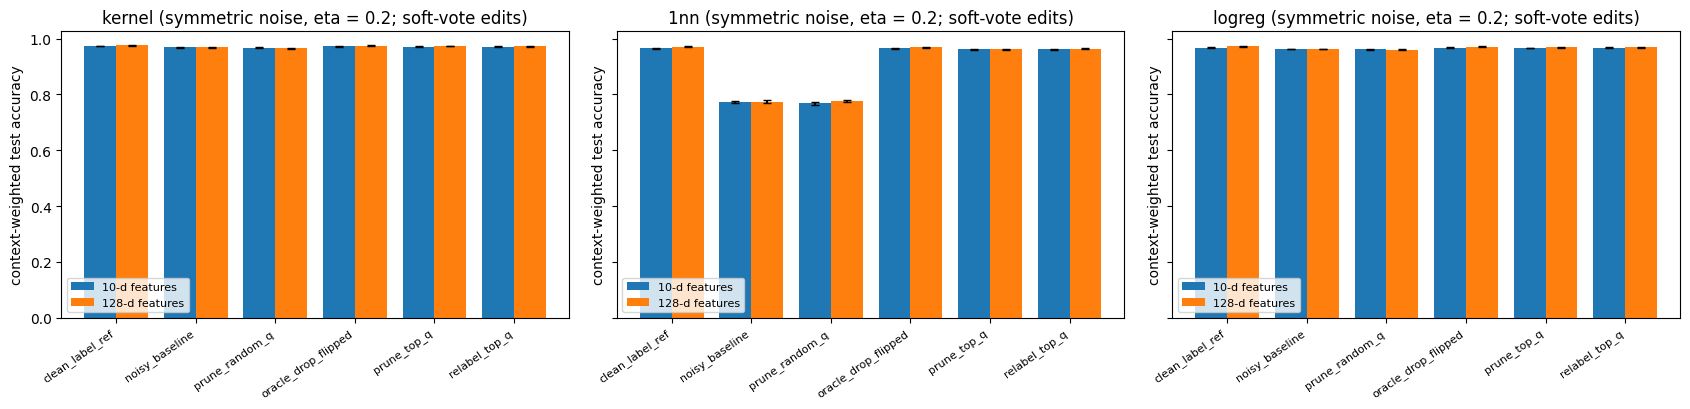

In [46]:
eta0, noise0 = ETAS[0], NOISE_TYPES[0]
order = ["clean_label_ref", "noisy_baseline", "prune_random_q", "oracle_drop_flipped",
         "prune_top_q", "relabel_top_q"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), sharey=True)
for ax, predictor in zip(axes, ["kernel", "1nn", "logreg"]):
    block = SUMMARY_C[(SUMMARY_C.noise == noise0) & (SUMMARY_C.eta == eta0) & (SUMMARY_C.predictor == predictor)
                      & SUMMARY_C.score.isin(["none", "soft_vote"])]
    for j, dim in enumerate(sorted(block["dim"].unique())):
        rows = block[block.dim == dim].set_index("intervention").loc[order]
        ax.bar(np.arange(len(order)) + (j - 0.5) * 0.4, rows["context_mean_mean"], 0.4,
               yerr=rows["context_mean_se"], capsize=3, label=f"{dim}-d features")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("context-weighted test accuracy")
    ax.set_title(f"{predictor} ({noise0} noise, eta = {eta0:g}; soft-vote edits)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**How to read this:** for each predictor, the context-weighted test accuracy of every edited context (soft-vote score for the score-based edits), with the full and the 10-d features side by side. Bars that match `noisy_baseline` mean the edit does not change what the predictor gets right. Bars approaching `clean_label_ref` mean the edit recovers what the noise cost.

# 5. Table D: native TFM with context resampling

Mirrors paper Table 4 / D.4.

TabICLv2 (or the `stub` stand-in) receives the same standardised 128-d CNN features. Interventions **resample** the context: n rows drawn with replacement, probability ∝ $m_i = 1 + λ[L_i \ge Q_{0.95}(L)]$, λ ∈ {3, 8, 15}. Scores:
* `crossfit_tfm`: 5-fold cross-fitted $1 - p(y_i)$ from the TFM itself (main);
* `tabicl_embedding`: Eq. 9 on TabICL's query-role embeddings, with γ from the median heuristic on the embeddings (secondary). This score is **not label-honest**: each point's own label is in the context when its embedding is computed.

Controls:
* (a) the full context, not resampled;
* (b) **uniform resampling** ($m = 1$): the right comparison for every resampled row, because resampling itself (duplicates, fewer unique rows) changes a TFM's input;
* (c) random-tail resampling at λ = 8;
* (d) the same resampling through the frozen kernel head, as `kernel_resampled` (realised multiplicities) vs `kernel_deterministic` (the weights $m$ themselves).

On (d): their difference is the frozen-head sampling term of paper Eq. D.7 *for the kernel head on CNN features*. It does **not** decompose TabICL's own response.

Each setting is drawn `TFM_DRAWS` times per seed. Accuracies (not predictions) are averaged over draws, then mean ± SE is taken over seeds. **Table D does not measure $E_i$ or validate the frozen-head explanation.**

## 5.1 Runtime estimate

In [47]:
assert all(seed in SEED_DATA for seed in TABLE_D_SEEDS), "run Section 0 first"
d = SEED_DATA[TABLE_D_SEEDS[0]]
t0 = time.time()
tfm_fit_predict(BACKEND, TABLE_D_SEEDS[0], DEVICE, d["X_ctx"], d["ctx"]["y"], d["X_test"])
one_fit = time.time() - t0
n_scores = 2 if BACKEND == "tabicl" else 1
fits_per_seed = 1 + CROSSFIT_FOLDS + (n_scores - 1) + TFM_DRAWS * (2 + n_scores * len(TFM_LAMS))
print(f"backend {BACKEND}: one fit + predict ({len(d['X_ctx'])} context rows, {len(d['X_test'])} test rows) "
      f"took {one_fit:.1f}s (the first TabICL call also downloads the checkpoint; re-run for a cleaner time)")
print(f"estimated Table D runtime: about {fits_per_seed} fits per seed x {len(TABLE_D_SEEDS)} seeds "
      f"= {fits_per_seed * len(TABLE_D_SEEDS) * one_fit / 60:.0f} min")
if BACKEND == "tabicl" and DEVICE == "cpu":
    print("WARNING: TabICL on CPU. Consider a GPU runtime or TABLE_D_SEEDS = SEEDS[:5].")

INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt: reconstructing file:   0%|          |  0.00B /  110MB            

tabicl-classifier-v2-20260212.ckpt: downloading bytes:           |  0.00B            

backend tabicl: one fit + predict (6000 context rows, 4000 test rows) took 4.3s (the first TabICL call also downloads the checkpoint; re-run for a cleaner time)
estimated Table D runtime: about 47 fits per seed x 10 seeds = 34 min


## 5.2 TFM difficulty scores and detection

In [48]:
t0 = time.time()
TFM_SCORES, TFM_EMB_GAMMA = {}, {}
for seed in TABLE_D_SEEDS:
    d = SEED_DATA[seed]
    y = d["ctx"]["y"]
    set_all_seeds(seed)
    TFM_SCORES[seed] = {"crossfit_tfm": crossfit_score(make_tfm(BACKEND, seed, DEVICE), d["X_ctx"], y, seed)}
    if BACKEND == "tabicl":
        L_emb, gamma_emb = tabicl_embedding_score(d["X_ctx"], y, seed, RUN_LOG)
        if L_emb is not None:
            TFM_SCORES[seed]["tabicl_embedding"] = L_emb
            TFM_EMB_GAMMA[seed] = gamma_emb
    print(f"seed {seed}: TFM scores done ({time.time() - t0:.0f}s)")

auc_rows = []
for seed in TABLE_D_SEEDS:
    for score, L in TFM_SCORES[seed].items():
        auc_rows.append({"seed": seed, "score": score, "auc": detection_auc(L, SEED_DATA[seed]["ctx"]["g"] > 0)})
print("DIAGNOSTIC: detection AUC of each TFM score for rare vs clean context points")
display(mean_se_table(mean_and_se(pd.DataFrame(auc_rows), ["score"], ["auc"]), ["score"], ["auc"]))

seed 0: TFM scores done (6s)
seed 1: TFM scores done (11s)
seed 2: TFM scores done (17s)
seed 3: TFM scores done (23s)
seed 4: TFM scores done (29s)
seed 5: TFM scores done (34s)
seed 6: TFM scores done (40s)
seed 7: TFM scores done (46s)
seed 8: TFM scores done (52s)
seed 9: TFM scores done (57s)
DIAGNOSTIC: detection AUC of each TFM score for rare vs clean context points


,score,auc,n_seeds
0,crossfit_tfm,0.900 ± 0.003,10
1,tabicl_embedding,0.794 ± 0.005,10


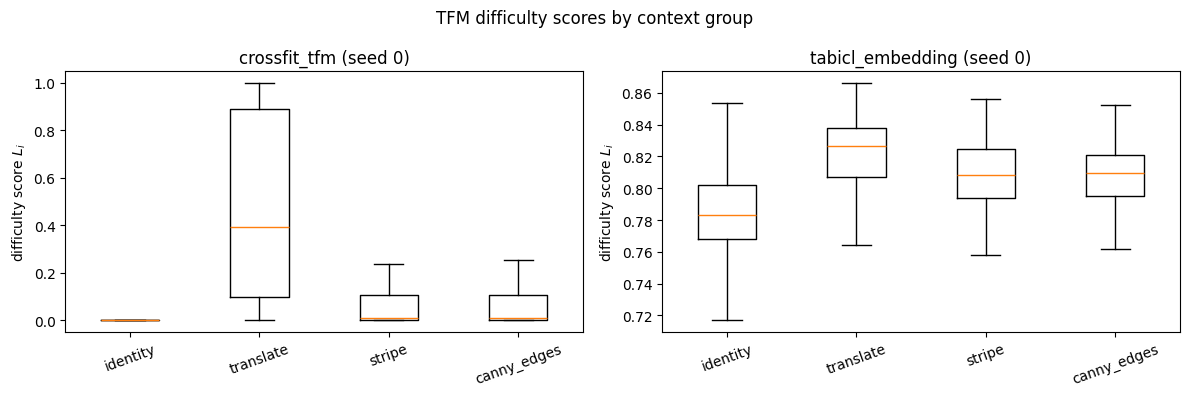

In [49]:
seed = TABLE_D_SEEDS[0]
names = list(TFM_SCORES[seed].keys())
fig, axes = plt.subplots(1, len(names), figsize=(6 * len(names), 4), squeeze=False)
for ax, score in zip(axes[0], names):
    plot_score_by_group(ax, TFM_SCORES[seed][score], SEED_DATA[seed]["ctx"]["g"], VERSIONS,
                        f"{score} (seed {seed})")
fig.suptitle("TFM difficulty scores by context group")
plt.tight_layout()
plt.show()

**How to read this:** the same reading as the Table A diagnostic, now for the TFM's own scores. Compare them with the Table A scores: the cross-fitted TFM score asks whether the TFM, given the other folds as context, predicts each point, while the embedding score asks whether a point's TabICL neighbours share its label.

## 5.3 Resampling runs

In [50]:
t0 = time.time()
ROWS_D = []
for seed in TABLE_D_SEEDS:
    d = SEED_DATA[seed]
    full = tfm_fit_predict(BACKEND, seed, DEVICE, d["X_ctx"], d["ctx"]["y"], d["X_test"])
    ROWS_D.append({"seed": seed, "predictor": "tfm", "score": "none", "intervention": "full_context",
                   "lam": np.nan, "draw": 0,
                   **group_accuracy_metrics(full, d["test"]["y"], d["test"]["g"], R + 1, d["rho"])})
    for k, (score, intervention, lam, m) in enumerate(table_d_settings(seed, TFM_SCORES[seed], len(d["ctx"]["y"]))):
        for draw in range(TFM_DRAWS):
            rng = np.random.default_rng([seed, k, draw])
            for predictor, metrics in run_resample_draw(seed, m, d, rng).items():
                ROWS_D.append({"seed": seed, "predictor": predictor, "score": score,
                               "intervention": intervention, "lam": lam, "draw": draw, **metrics})
    print(f"seed {seed}: Table D done ({time.time() - t0:.0f}s)")
DF_D = pd.DataFrame(ROWS_D)

seed 0: Table D done (61s)
seed 1: Table D done (121s)
seed 2: Table D done (182s)
seed 3: Table D done (243s)
seed 4: Table D done (303s)
seed 5: Table D done (364s)
seed 6: Table D done (425s)
seed 7: Table D done (487s)
seed 8: Table D done (548s)
seed 9: Table D done (609s)


## 5.4 Results

In [51]:
keys = ["seed", "predictor", "score", "intervention", "lam"]
PER_SEED_D = DF_D.groupby(keys, dropna=False)[METRICS + GROUP_METRICS].mean().reset_index()  # average draws
SUMMARY_D = mean_and_se(PER_SEED_D, keys[1:], METRICS + GROUP_METRICS)
print("Table D: test accuracy (accuracies averaged over draws, then mean ± SE over seeds)")
display(mean_se_table(SUMMARY_D, keys[1:], METRICS))
diffs_d = paired_differences(PER_SEED_D, "worst_group", "uniform_resample", ["predictor"],
                             ["score", "intervention", "lam"])
print("Paired per-seed difference in worst-group accuracy vs uniform resampling (same predictor):")
display(mean_se_table(diffs_d, ["predictor", "score", "intervention", "lam"], ["diff"]))

Table D: test accuracy (accuracies averaged over draws, then mean ± SE over seeds)


,predictor,score,intervention,lam,worst_group,balanced_mean,context_mean,worst_cell,n_seeds
0,kernel_deterministic,crossfit_tfm,tail_resample,3.0,0.605 ± 0.006,0.841 ± 0.003,0.974 ± 0.001,0.347 ± 0.014,10
1,kernel_deterministic,crossfit_tfm,tail_resample,8.0,0.605 ± 0.006,0.833 ± 0.004,0.969 ± 0.002,0.376 ± 0.016,10
2,kernel_deterministic,crossfit_tfm,tail_resample,15.0,0.600 ± 0.006,0.820 ± 0.004,0.963 ± 0.001,0.392 ± 0.015,10
3,kernel_deterministic,none,random_tail_resample,8.0,0.582 ± 0.005,0.836 ± 0.002,0.975 ± 0.001,0.304 ± 0.017,10
4,kernel_deterministic,none,uniform_resample,NaN,0.590 ± 0.005,0.843 ± 0.002,0.976 ± 0.001,0.309 ± 0.016,10
5,kernel_deterministic,tabicl_embedding,tail_resample,3.0,0.600 ± 0.006,0.840 ± 0.003,0.975 ± 0.002,0.347 ± 0.014,10
6,kernel_deterministic,tabicl_embedding,tail_resample,8.0,0.593 ± 0.006,0.830 ± 0.004,0.970 ± 0.002,0.365 ± 0.018,10
7,kernel_deterministic,tabicl_embedding,tail_resample,15.0,0.581 ± 0.006,0.819 ± 0.004,0.966 ± 0.002,0.366 ± 0.021,10
8,kernel_resampled,crossfit_tfm,tail_resample,3.0,0.590 ± 0.005,0.829 ± 0.003,0.972 ± 0.001,0.332 ± 0.016,10
9,kernel_resampled,crossfit_tfm,tail_resample,8.0,0.590 ± 0.005,0.817 ± 0.004,0.967 ± 0.001,0.358 ± 0.012,10


Paired per-seed difference in worst-group accuracy vs uniform resampling (same predictor):


,predictor,score,intervention,lam,diff,n_seeds
0,kernel_deterministic,crossfit_tfm,tail_resample,3.0,0.014 ± 0.002,10
1,kernel_deterministic,crossfit_tfm,tail_resample,8.0,0.015 ± 0.004,10
2,kernel_deterministic,crossfit_tfm,tail_resample,15.0,0.010 ± 0.004,10
3,kernel_deterministic,none,random_tail_resample,8.0,-0.009 ± 0.002,10
4,kernel_deterministic,none,uniform_resample,NaN,0.000 ± 0.000,10
5,kernel_deterministic,tabicl_embedding,tail_resample,3.0,0.010 ± 0.001,10
6,kernel_deterministic,tabicl_embedding,tail_resample,8.0,0.003 ± 0.002,10
7,kernel_deterministic,tabicl_embedding,tail_resample,15.0,-0.009 ± 0.004,10
8,kernel_resampled,crossfit_tfm,tail_resample,3.0,0.029 ± 0.003,10
9,kernel_resampled,crossfit_tfm,tail_resample,8.0,0.029 ± 0.004,10


**How to read this:**
* First table: `tfm` rows are the native model; `kernel_*` rows are control (d).
* Second table: each condition's per-seed difference from **uniform resampling** for the same predictor. That isolates the effect of *which* points are upweighted from the effect of resampling itself. Compare `tail_resample` with `random_tail_resample` at λ = 8.
* `full_context` vs `uniform_resample` (for `tfm`) shows what resampling alone costs or gains.
* `kernel_resampled` vs `kernel_deterministic` shows how far a finite resampled context departs from deterministic reweighting for the frozen kernel head.

## 5.5 Figure

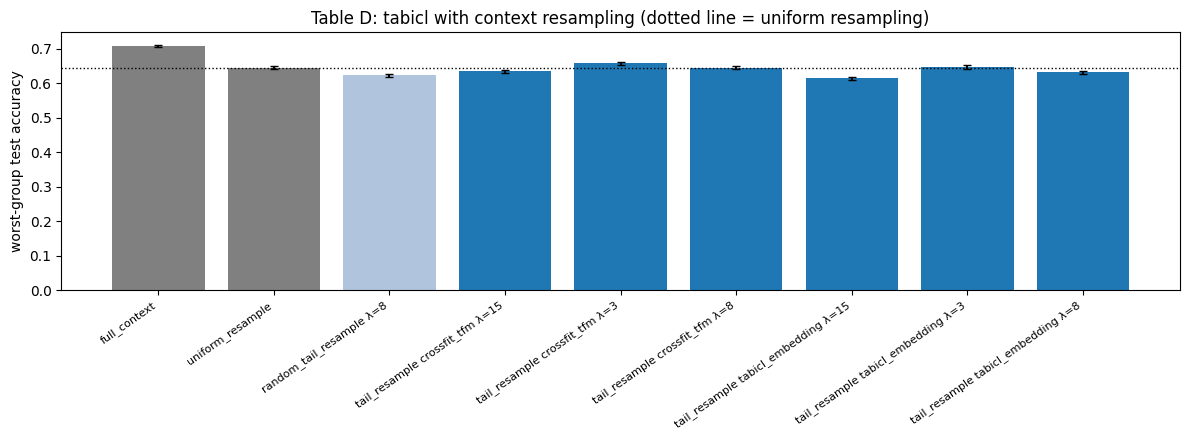

In [52]:
def table_d_condition(row):
    """Readable Table D label, e.g. 'tail_resample crossfit_tfm λ=8'."""
    label = row["intervention"]
    if row["score"] != "none":
        label += " " + row["score"]
    if not np.isnan(row["lam"]):
        label += f" λ={row['lam']:g}"
    return label


tfm_rows = SUMMARY_D[SUMMARY_D.predictor == "tfm"].copy()
tfm_rows["condition"] = tfm_rows.apply(table_d_condition, axis=1)
first = ["full_context", "uniform_resample"]
tfm_rows["order"] = [0 if c in first else 1 for c in tfm_rows.intervention]
tfm_rows = tfm_rows.sort_values(["order", "condition"]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(tfm_rows))
ax.bar(x, tfm_rows["worst_group_mean"], yerr=tfm_rows["worst_group_se"], capsize=3,
       color=["grey" if c in first else "lightsteelblue" if c.startswith("random") else "tab:blue"
              for c in tfm_rows.intervention])
uniform = tfm_rows.loc[tfm_rows.intervention == "uniform_resample", "worst_group_mean"]
ax.axhline(uniform.iloc[0], ls=":", c="k", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(tfm_rows["condition"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("worst-group test accuracy")
ax.set_title(f"Table D: {BACKEND} with context resampling (dotted line = uniform resampling)")
plt.tight_layout()
plt.show()

**How to read this:** mean worst-group accuracy (±1 SE over seeds) of the native TFM for each resampling condition. Grey bars are the two controls without score-based selection. The dotted line is uniform resampling, the fair comparison for every blue (score-based) and light-blue (random-tail) bar.

# 6. Sanity-check summary

Checks 1, 2, 5 and 6 are hard asserts: if the notebook got this far, they passed. Checks 3 and 4 only warn, so their status is recorded here for you to judge.

In [53]:
expected_checks = ["1 label equality across folders", "2 no index reuse, exact stratification",
                   "3 corruption detectability", "4 baseline gap >= 0.10",
                   "5 Eq. 9 unit test", "6 fixed-feature negative control"]
for name in expected_checks:
    print(f"{name:45s} {SANITY.get(name, 'not run (its section was skipped)')}")
print("\nRun notes:" if RUN_LOG else "\nRun notes: none")
for note in RUN_LOG:
    print(" -", note)

1 label equality across folders               pass
2 no index reuse, exact stratification        pass (asserted for every context)
3 corruption detectability                    pass (0.858)
4 baseline gap >= 0.10                        pass
5 Eq. 9 unit test                             pass
6 fixed-feature negative control              pass

Run notes: none


# 7. Decisions

Declared defaults, and deviations from the experiment spec:

**Design and features**
* **Rare corruptions:** the R = 3 corruptions with the lowest pilot accuracy (mean of kernel head and logistic regression) among those above 0.30. The values are printed below.
* **CNN:** Conv(1→32, 3×3, pad 1) → ReLU → MaxPool(2) → Conv(32→64, 3×3, pad 1) → ReLU → MaxPool(2) → Linear(3136→128) → ReLU (features) → Linear(128→10). Trained with Adam, lr 1e-3, batch 128, 5 epochs (1 in smoke test), no augmentation, on clean CNN-pool images, with 10% held out. It is retrained every session and not cached.
* **Pixels:** divided by 255; the CNN takes 1×28×28 images, so a flattened 784-d vector is not used.

**Predictors and scores**
* **Kernel bandwidth (deviation from the paper's median heuristic):** γ maximises the mean frozen-LOO log-likelihood (Eq. 9) of the context labels over 25 values from the median rule (1 / median nonzero squared distance, all pairs) to 10⁴ × it. It is chosen once per seed on the baseline context and held fixed for every intervention and reference context of that seed. The 10-d features of Table C (chosen on clean labels), each ρ-sweep context and the pilot get their own γ by the same rule. Reason: in 128 dimensions the median rule averages over almost the whole context, making the kernel head a near class-prior vote. The median rule is still reported (secondary rows in Section 1, diagnostic in 1.2). The TabICL embedding score in Section 5 keeps the median rule on the embeddings.
* **Logistic regression:** C = 1.0, lbfgs, max_iter 2000. Points with m = 0 are dropped and the remaining weights rescaled to mean 1.
* **GP score:** one-hot regression with the same kernel, σ² = 0.1. σ² ∈ {0.01, 1.0} enters only the detection AUC and tail-composition tables (sensitivity), not the interventions.
* **Smooth / exponential rules:** p_i = 1 − L_i clipped to [1e-12, 1], s = −log p, s̃ = min–max normalised (s̃ = 0 if s is constant). Applied only to probability-type scores (soft-vote, cross-fitted).

**Interventions and selection**
* **Pruning:** removes exactly round(q·n) points by rank, ties broken by index. **Addition:** a `prune_random(q)` control in Table A, so pruning has a matched control as in Table C.
* **Validation selection:** chosen separately for every predictor/score pair; it uses group labels and is labelled as such.
* **Context-weighted mean:** uses the realised ρ of the main context for every Table A row, including the balanced reference (whose own context is 75% rare). This keeps all rows comparable on one target distribution.
* **ρ sweep:** each (seed, ρ) context refits its own scaler and γ. Rounding is max(1, round(600·ρ/R)); the realised ρ is reported.
* **Table C:** q = η. `relabel_top_q` always uses the argmax of the frozen LOO soft-vote prediction, even when the GP score selects the points. Asymmetric map: 1→7, 7→1, 3→8, 8→3, 4→9, 9→4, 5→6, 6→5, 2→7, 0→6.
* **Table D:** accuracies are averaged over draws (predictions are not ensembled). The random-tail control has the size of the cross-fitted score's τ = 0.95 tail. Control (d) measures the frozen-head sampling term for the kernel head on CNN features only.

**Sanity checks and diagnostics**
* **Check 3 (deviation):** reports **balanced** accuracy of a class-weighted logistic regression. With 95% clean points, plain accuracy would pass by predicting "clean" every time.
* **Bandwidth diagnostic (addition):** the median effective number of neighbours of the kernel head (weight perplexity) is reported next to the detection AUCs.

**Code organisation (deviation, agreed with the user)**
* Reusable helpers live in the `kernel_louis` package, with tests in `tests/test_rare_corruption.py`, instead of inside this notebook. The first cell clones the repository.

In [54]:
print("rare corruptions (pilot):", RARE_CORRUPTIONS, "| groups:", VERSIONS)
print(f"CNN held-out clean accuracy: {CNN_HOLDOUT_ACC:.4f}")
print("SMOKE_TEST:", SMOKE_TEST, "| seeds:", SEEDS, "| Table D seeds:", TABLE_D_SEEDS)
print("device:", DEVICE, "| Table D backend:", BACKEND, "| tabicl version:", TABICL_VERSION)
if BACKEND == "tabicl":
    print("TabICL checkpoint:", make_tfm("tabicl", 0, DEVICE).checkpoint_version)
print("kernel gamma per seed (selected):", {seed: float(f"{SEED_DATA[seed]['gamma']:.4g}") for seed in SEED_DATA})
print("kernel gamma per seed (median rule):", {seed: float(f"{SEED_DATA[seed]['gamma_median']:.4g}") for seed in SEED_DATA})
if "TFM_EMB_GAMMA" in globals():
    print("TabICL embedding gamma per seed:", {s: float(f"{gm:.4g}") for s, gm in TFM_EMB_GAMMA.items()})
if "SELECTED" in globals():
    print("validation-selected (tau, lam) per predictor/score:",
          {f"{p}/{s}": (float(t), float(l)) for (p, s), (t, l) in SELECTED.items()})

rare corruptions (pilot): ['translate', 'stripe', 'canny_edges'] | groups: ['identity', 'translate', 'stripe', 'canny_edges']
CNN held-out clean accuracy: 0.9790
SMOKE_TEST: False | seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] | Table D seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
device: cuda | Table D backend: tabicl | tabicl version: 2.1.1
TabICL checkpoint: tabicl-classifier-v2-20260212.ckpt
kernel gamma per seed (selected): {0: 0.1865, 1: 0.1865, 2: 0.1866, 3: 0.1866, 4: 0.1866, 5: 0.186, 6: 0.1863, 7: 0.1864, 8: 0.1862, 9: 0.1862}
kernel gamma per seed (median rule): {0: 0.005899, 1: 0.005896, 2: 0.0059, 3: 0.005902, 4: 0.005899, 5: 0.005882, 6: 0.005893, 7: 0.005895, 8: 0.00589, 9: 0.005889}
TabICL embedding gamma per seed: {0: 9.833e-05, 1: 9.466e-05, 2: 0.0001004, 3: 9.226e-05, 4: 9.683e-05, 5: 9.502e-05, 6: 0.000102, 7: 9.809e-05, 8: 9.752e-05, 9: 0.0001016}
validation-selected (tau, lam) per predictor/score: {'kernel/soft_vote': (0.95, 8.0), 'kernel/gp_0.1': (0.9, 20.0), 'logreg/crossfit_

# 8. Results summary

Generated from the result tables above; nothing is hard-coded. Sections that were not run are skipped.

In [55]:
def fmt(row, metric):
    """'mean ± SE' text of one summary row."""
    return f"{row[metric + '_mean']:.3f} ± {row[metric + '_se']:.3f}"


print(f"Run: SMOKE_TEST={SMOKE_TEST}, {len(SEEDS)} seeds, n={N_PER_CLASS * N_CLASSES}, rho={RHO}, "
      f"R={R} ({', '.join(RARE_CORRUPTIONS)}), test {TEST_PER_CLASS * N_CLASSES} digits x {R + 1} versions")
if "SUMMARY_A" in globals():
    print(f"\nTable A (test; tau grid {TAUS}, lambda grid {LAMS}): worst-group | balanced mean")
    for predictor, score, role in PAIRS_A:
        conditions = main_conditions(SELECTED[(predictor, score)])
        for _, row in table_a_main(SUMMARY_A, predictor, score, conditions).iterrows():
            print(f"  {predictor:6s} {score:16s} {row['condition']:28s} {fmt(row, 'worst_group')} | "
                  f"{fmt(row, 'balanced_mean')}  {row['setting']}")
if "TABLE_B" in globals():
    print("\nTable B (tau = 0.95): detection AUC | tail precision | recall")
    for _, row in summary_b[summary_b.tau == 0.95].iterrows():
        print(f"  {row['score']:16s} {fmt(row, 'auc')} | {fmt(row, 'precision')} | {fmt(row, 'recall')}")

Run: SMOKE_TEST=False, 10 seeds, n=6000, rho=0.05, R=3 (translate, stripe, canny_edges), test 1000 digits x 4 versions

Table A (test; tau grid [0.8, 0.9, 0.95, 0.97, 0.99], lambda grid [2, 8, 20]): worst-group | balanced mean
  kernel soft_vote        baseline                     0.590 ± 0.005 | 0.843 ± 0.002  
  kernel soft_vote        tail(0.95, 8)                0.615 ± 0.005 | 0.834 ± 0.003  pre-registered
  kernel soft_vote        random_tail(0.95, 8)         0.585 ± 0.006 | 0.838 ± 0.002  control for pre-registered
  kernel soft_vote        tail(0.95, 8)                0.615 ± 0.005 | 0.834 ± 0.003  validation-selected (uses group labels)
  kernel soft_vote        random_tail(0.95, 8)         0.585 ± 0.006 | 0.838 ± 0.002  control for validation-selected
  kernel soft_vote        prune(0.05)                  0.516 ± 0.006 | 0.819 ± 0.002  
  kernel soft_vote        prune_random(0.05)           0.589 ± 0.005 | 0.841 ± 0.002  control
  kernel soft_vote        prune(0.1)           

In [56]:
if "SUMMARY_RHO" in globals():
    print("rho sweep: worst-group accuracy (baseline | tail | random_tail | oracle_balance)")
    for predictor in ["kernel", "logreg"]:
        for rho in RHOS:
            rows = SUMMARY_RHO[(SUMMARY_RHO.predictor == predictor) & (SUMMARY_RHO.rho == rho)].set_index("intervention")
            print(f"  {predictor:6s} rho={rho:<6g}" + " | ".join(
                fmt(rows.loc[i], "worst_group") for i in ["baseline", "tail", "random_tail", "oracle_balance"]))
if "SUMMARY_C" in globals():
    print("\nTable C: context-weighted accuracy (clean ref | noisy | prune_top_q soft-vote | oracle drop)")
    wanted = [("clean_label_ref", "none"), ("noisy_baseline", "none"), ("prune_top_q", "soft_vote"),
              ("oracle_drop_flipped", "none")]
    for (dim, noise, eta, predictor), block in SUMMARY_C.groupby(["dim", "noise", "eta", "predictor"]):
        texts = []
        for name, score in wanted:
            row = block[(block.intervention == name) & (block.score == score)].iloc[0]
            texts.append(fmt(row, "context_mean"))
        print(f"  {dim:>3}-d {noise:10s} eta={eta:<4g} {predictor:6s} " + " | ".join(texts))
if "SUMMARY_D" in globals():
    print(f"\nTable D ({BACKEND}, {len(TABLE_D_SEEDS)} seeds, {TFM_DRAWS} draws): worst-group accuracy")
    for _, row in SUMMARY_D[SUMMARY_D.predictor == "tfm"].iterrows():
        lam = "" if np.isnan(row["lam"]) else f" lambda={row['lam']:g}"
        print(f"  {row['intervention']:22s} {row['score']:18s}{lam:12s} {fmt(row, 'worst_group')}")

rho sweep: worst-group accuracy (baseline | tail | random_tail | oracle_balance)
  kernel rho=0.01  0.515 ± 0.006 | 0.521 ± 0.006 | 0.512 ± 0.006 | 0.512 ± 0.006
  kernel rho=0.025 0.543 ± 0.006 | 0.553 ± 0.006 | 0.541 ± 0.007 | 0.560 ± 0.008
  kernel rho=0.05  0.585 ± 0.007 | 0.605 ± 0.006 | 0.573 ± 0.007 | 0.625 ± 0.008
  kernel rho=0.1   0.644 ± 0.006 | 0.675 ± 0.006 | 0.630 ± 0.008 | 0.697 ± 0.008
  logreg rho=0.01  0.492 ± 0.007 | 0.480 ± 0.008 | 0.489 ± 0.007 | 0.527 ± 0.008
  logreg rho=0.025 0.528 ± 0.008 | 0.526 ± 0.008 | 0.528 ± 0.005 | 0.569 ± 0.008
  logreg rho=0.05  0.577 ± 0.009 | 0.564 ± 0.009 | 0.570 ± 0.009 | 0.611 ± 0.009
  logreg rho=0.1   0.629 ± 0.005 | 0.618 ± 0.005 | 0.625 ± 0.005 | 0.668 ± 0.007

Table C: context-weighted accuracy (clean ref | noisy | prune_top_q soft-vote | oracle drop)
   10-d asymmetric eta=0.2  1nn    0.966 ± 0.002 | 0.775 ± 0.004 | 0.950 ± 0.003 | 0.966 ± 0.002
   10-d asymmetric eta=0.2  kernel 0.974 ± 0.002 | 0.968 ± 0.002 | 0.971 ± 0.001

# 9. Interpretation (fill in after the full run)

Guardrails. Check each before writing:
- [ ] Detection quality (AUC, tail precision) and intervention value (accuracy change) are reported and discussed **separately**; a high AUC is not evidence that reweighting helps.
- [ ] Pruning flagged points in Table A is described as removing (mostly valid) rare examples, **not** as "cleaning".
- [ ] Validation-selected τ/λ is described as **using group labels**, never as group-label-free.
- [ ] Table D is not described as measuring $E_i$ or validating the frozen-head explanation.
- [ ] Effects are judged on paired differences against the right control (random tail; uniform resampling in Table D), with their SEs.
- [ ] Any sanity-check warnings above are mentioned.

## Detection (Table A diagnostic, Table B, ρ sweep)

## Intervention value (Table A, ρ sweep)

## Label noise (Table C)

## Native TFM (Table D)

## Limitations